`label_ids_to_fuse` unset. No instance will be fused.


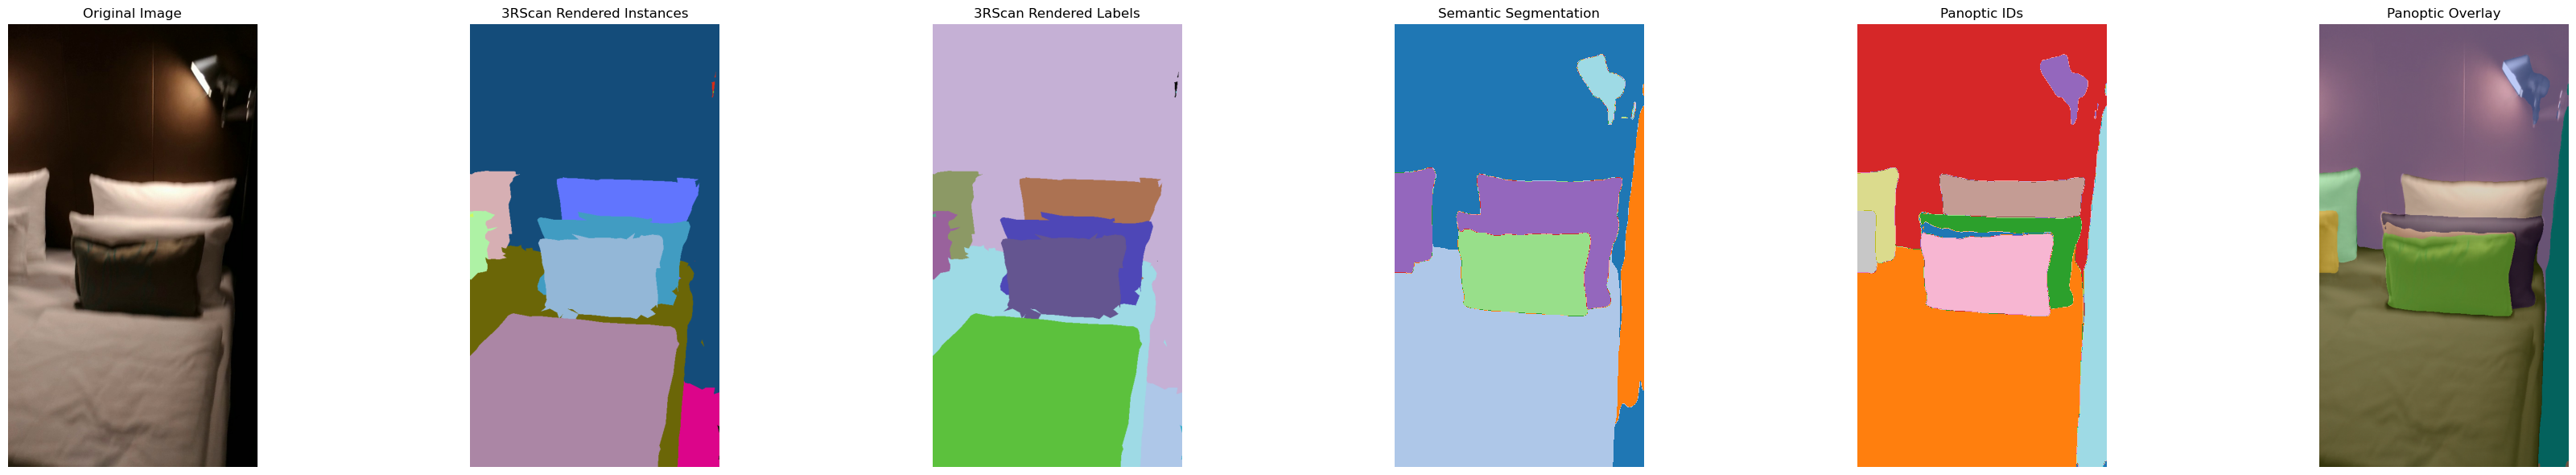

Panoptic segments detected: 9
{'id': 1, 'label_id': 7, 'was_fused': False, 'score': 0.987269, 'label_name': 'bed '}
{'id': 2, 'label_id': 57, 'was_fused': False, 'score': 0.99809, 'label_name': 'pillow'}
{'id': 3, 'label_id': 0, 'was_fused': False, 'score': 0.999293, 'label_name': 'wall'}
{'id': 4, 'label_id': 134, 'was_fused': False, 'score': 0.981049, 'label_name': 'sconce'}
{'id': 5, 'label_id': 57, 'was_fused': False, 'score': 0.992139, 'label_name': 'pillow'}
{'id': 6, 'label_id': 39, 'was_fused': False, 'score': 0.988688, 'label_name': 'cushion'}
{'id': 7, 'label_id': 57, 'was_fused': False, 'score': 0.987867, 'label_name': 'pillow'}
{'id': 8, 'label_id': 57, 'was_fused': False, 'score': 0.995894, 'label_name': 'pillow'}
{'id': 9, 'label_id': 18, 'was_fused': False, 'score': 0.930122, 'label_name': 'curtain'}


In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# Use a COCO-panoptic checkpoint to match the COCO sample image.
checkpoint = "facebook/mask2former-swin-large-ade-panoptic"
processor = AutoImageProcessor.from_pretrained(checkpoint)
model = Mask2FormerForUniversalSegmentation.from_pretrained(checkpoint)

image_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.color.jpg"
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Local image not found: {image_path}")

instances_path = image_path.replace(".color.jpg", ".rendered.instances.png")
labels_path = image_path.replace(".color.jpg", ".rendered.labels.png")

if not os.path.exists(instances_path):
    raise FileNotFoundError(f"Rendered instances image not found: {instances_path}")
if not os.path.exists(labels_path):
    raise FileNotFoundError(f"Rendered labels image not found: {labels_path}")

image = Image.open(image_path).convert("RGB")
image = image.rotate(-90, expand=True)

def align_to_reference_orientation(img, reference_size):
    if img.size == reference_size:
        return img
    candidates = [
        img.rotate(-90, expand=True),
        img.rotate(90, expand=True),
        img.rotate(180, expand=True),
    ]
    for candidate in candidates:
        if candidate.size == reference_size:
            return candidate
    return img

rendered_instances = Image.open(instances_path).convert("RGB")
rendered_instances = align_to_reference_orientation(rendered_instances, image.size)

rendered_labels = Image.open(labels_path)
rendered_labels = align_to_reference_orientation(rendered_labels, image.size)

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# Panoptic output.
panoptic = processor.post_process_panoptic_segmentation(
    outputs,
    target_sizes=[image.size[::-1]],
    threshold=0.3,
    mask_threshold=0.3,
    overlap_mask_area_threshold=0.7,
)[0]

predicted_panoptic_map = panoptic["segmentation"].cpu().numpy()
segments_info = panoptic["segments_info"]

# Semantic output for comparison.
semantic = processor.post_process_semantic_segmentation(
    outputs, target_sizes=[image.size[::-1]]
)[0].cpu().numpy()

# Colorize panoptic ids.
unique_ids = np.unique(predicted_panoptic_map)
rng = np.random.default_rng(0)
colors = rng.random((len(unique_ids), 3), dtype=np.float32)
color_map = {int(seg_id): colors[i] for i, seg_id in enumerate(unique_ids)}

panoptic_color = np.zeros((*predicted_panoptic_map.shape, 3), dtype=np.float32)
for seg_id in unique_ids:
    panoptic_color[predicted_panoptic_map == seg_id] = color_map[int(seg_id)]

# Blend panoptic colors over the original image.
image_np = np.array(image).astype(np.float32) / 255.0
alpha = 0.5
overlay = (1 - alpha) * image_np + alpha * panoptic_color

# Decode 3RScan rendered instance encoding to readable colors.
rendered_instances_np = np.array(rendered_instances, dtype=np.uint8)
if rendered_instances_np.ndim == 3:
    if np.array_equal(rendered_instances_np[..., 0], rendered_instances_np[..., 1]) and np.array_equal(rendered_instances_np[..., 1], rendered_instances_np[..., 2]):
        rendered_instance_ids = rendered_instances_np[..., 0].astype(np.int32)
    else:
        rendered_instance_ids = (
            rendered_instances_np[..., 0].astype(np.int32)
            + (rendered_instances_np[..., 1].astype(np.int32) << 8)
            + (rendered_instances_np[..., 2].astype(np.int32) << 16)
        )
else:
    rendered_instance_ids = rendered_instances_np.astype(np.int32)

instance_unique_ids = np.unique(rendered_instance_ids)
instance_colors = rng.random((len(instance_unique_ids), 3), dtype=np.float32)
instance_color_map = {int(seg_id): instance_colors[i] for i, seg_id in enumerate(instance_unique_ids)}

rendered_instances_vis = np.zeros((*rendered_instance_ids.shape, 3), dtype=np.float32)
for seg_id in instance_unique_ids:
    rendered_instances_vis[rendered_instance_ids == seg_id] = instance_color_map[int(seg_id)]

rendered_labels_np = np.array(rendered_labels)

fig, axes = plt.subplots(1, 6, figsize=(36, 6))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(rendered_instances_vis)
axes[1].set_title("3RScan Rendered Instances")
axes[1].axis("off")

if rendered_labels_np.ndim == 2:
    axes[2].imshow(rendered_labels_np, cmap="tab20")
else:
    axes[2].imshow(rendered_labels_np)
axes[2].set_title("3RScan Rendered Labels")
axes[2].axis("off")

axes[3].imshow(semantic, cmap="tab20")
axes[3].set_title("Semantic Segmentation")
axes[3].axis("off")

axes[4].imshow(predicted_panoptic_map, cmap="tab20")
axes[4].set_title("Panoptic IDs")
axes[4].axis("off")

axes[5].imshow(overlay)
axes[5].set_title("Panoptic Overlay")
axes[5].axis("off")

plt.tight_layout()
plt.show()

print(f"Panoptic segments detected: {len(segments_info)}")
for s in segments_info[:10]:
    label = model.config.id2label.get(s.get("label_id", -1), "unknown")
    print({**s, "label_name": label})

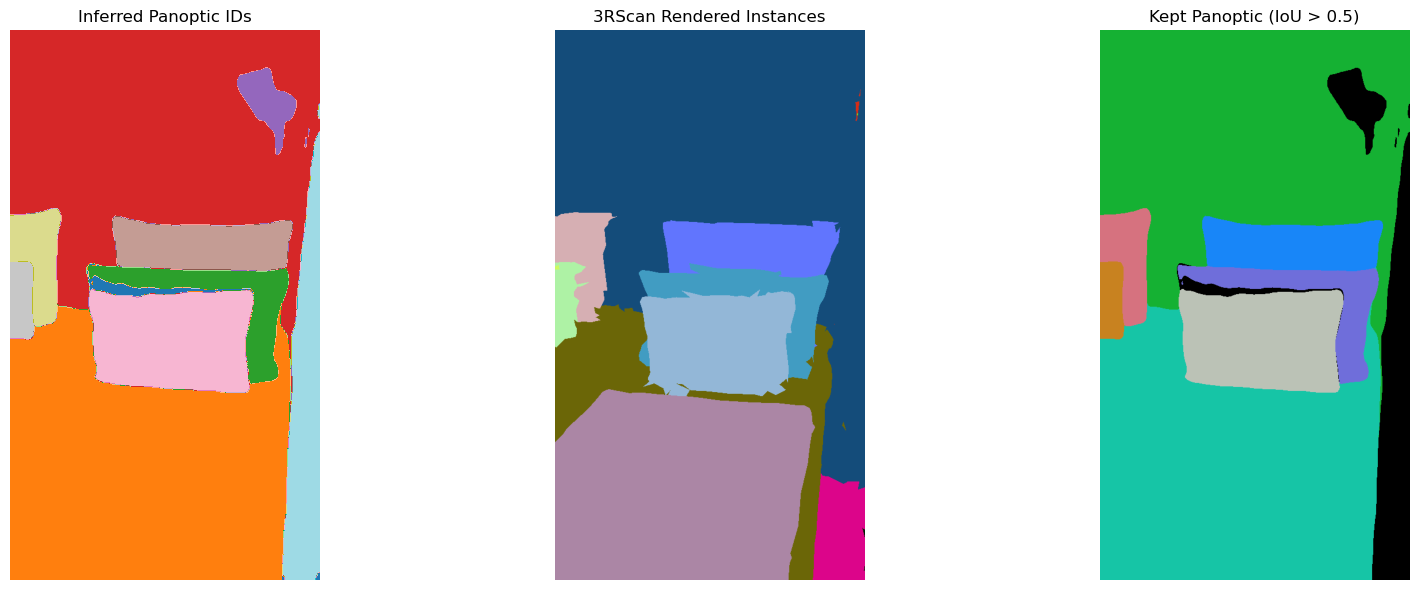

Total inferred panoptic instances (excluding 0): 9
Matched and kept instances (IoU > 0.3): 7
panoptic_id=1 -> rendered_id=25 | IoU=0.738
panoptic_id=2 -> rendered_id=26 | IoU=0.587
panoptic_id=3 -> rendered_id=9 | IoU=0.822
panoptic_id=5 -> rendered_id=27 | IoU=0.856
panoptic_id=6 -> rendered_id=47 | IoU=0.860
panoptic_id=7 -> rendered_id=29 | IoU=0.853
panoptic_id=8 -> rendered_id=30 | IoU=0.848


In [3]:
# Match inferred panoptic instances to 3RScan rendered instances using IoU.
iou_threshold = 0.3

if predicted_panoptic_map.shape != rendered_instance_ids.shape:
    raise ValueError(
        f"Shape mismatch: panoptic={predicted_panoptic_map.shape}, rendered={rendered_instance_ids.shape}"
    )

panoptic_ids = [int(x) for x in np.unique(predicted_panoptic_map) if int(x) != 0]
rendered_ids = [int(x) for x in np.unique(rendered_instance_ids) if int(x) != 0]

best_match_for_panoptic = {}
kept_panoptic_ids = set()

for pan_id in panoptic_ids:
    pan_mask = predicted_panoptic_map == pan_id
    pan_area = int(pan_mask.sum())
    if pan_area == 0:
        continue

    best_rendered_id = None
    best_iou = 0.0

    for rend_id in rendered_ids:
        rend_mask = rendered_instance_ids == rend_id
        inter = int(np.logical_and(pan_mask, rend_mask).sum())
        if inter == 0:
            continue
        union = pan_area + int(rend_mask.sum()) - inter
        iou = inter / union if union > 0 else 0.0

        if iou > best_iou:
            best_iou = iou
            best_rendered_id = rend_id

    if best_rendered_id is not None and best_iou > iou_threshold:
        best_match_for_panoptic[pan_id] = {
            "rendered_instance_id": best_rendered_id,
            "iou": best_iou,
        }
        kept_panoptic_ids.add(pan_id)

filtered_panoptic_map = np.zeros_like(predicted_panoptic_map)
for pan_id in kept_panoptic_ids:
    filtered_panoptic_map[predicted_panoptic_map == pan_id] = pan_id

# Create a color visualization for kept instances.
kept_ids = np.unique(filtered_panoptic_map)
kept_ids = kept_ids[kept_ids != 0]
filtered_color = np.zeros((*filtered_panoptic_map.shape, 3), dtype=np.float32)

local_rng = np.random.default_rng(42)
if len(kept_ids) > 0:
    kept_colors = local_rng.random((len(kept_ids), 3), dtype=np.float32)
    for i, pan_id in enumerate(kept_ids):
        filtered_color[filtered_panoptic_map == int(pan_id)] = kept_colors[i]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(predicted_panoptic_map, cmap="tab20")
axes[0].set_title("Inferred Panoptic IDs")
axes[0].axis("off")

axes[1].imshow(rendered_instances_vis)
axes[1].set_title("3RScan Rendered Instances")
axes[1].axis("off")

axes[2].imshow(filtered_color)
axes[2].set_title("Kept Panoptic (IoU > 0.5)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Total inferred panoptic instances (excluding 0): {len(panoptic_ids)}")
print(f"Matched and kept instances (IoU > {iou_threshold}): {len(best_match_for_panoptic)}")
for pan_id, info in sorted(best_match_for_panoptic.items()):
    print(
        f"panoptic_id={pan_id} -> rendered_id={info['rendered_instance_id']} | IoU={info['iou']:.3f}"
    )

Scan: 0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca
Kept rendered instance IDs: [9, 25, 26, 27, 29, 30, 47]
Visible object IDs from frame: [1, 9, 17, 23, 25, 26, 27, 28, 29, 30, 36, 47]
Candidate object IDs used for relationships: [9, 25, 26, 27, 29, 30, 47]
Filtered relationships among kept objects: 92


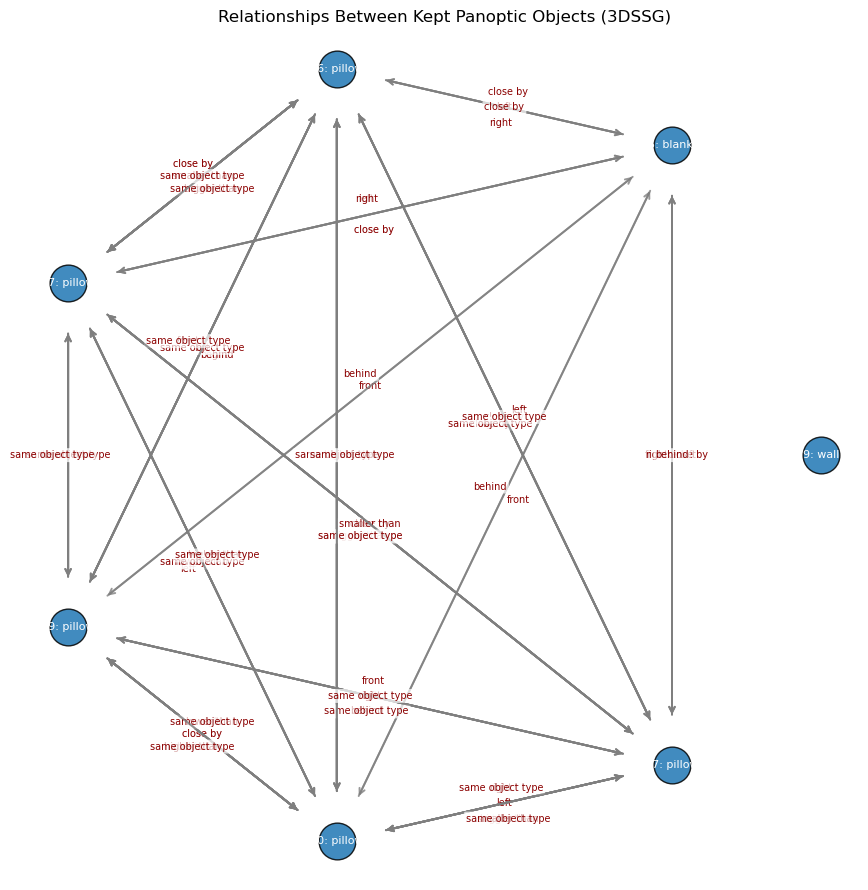

Relationships:
25:blanket --[6:close by]--> 26:pillow
25:blanket --[2:left]--> 26:pillow
25:blanket --[6:close by]--> 27:pillow
25:blanket --[2:left]--> 27:pillow
25:blanket --[4:front]--> 29:pillow
25:blanket --[4:front]--> 30:pillow
25:blanket --[4:front]--> 47:pillow
25:blanket --[6:close by]--> 47:pillow
25:blanket --[2:left]--> 47:pillow
26:pillow --[3:right]--> 25:blanket
26:pillow --[6:close by]--> 25:blanket
26:pillow --[4:front]--> 27:pillow
26:pillow --[6:close by]--> 27:pillow
26:pillow --[2:left]--> 27:pillow
26:pillow --[3:right]--> 29:pillow
26:pillow --[4:front]--> 29:pillow
26:pillow --[3:right]--> 30:pillow
26:pillow --[4:front]--> 30:pillow
26:pillow --[3:right]--> 47:pillow
26:pillow --[6:close by]--> 47:pillow
27:pillow --[3:right]--> 25:blanket
27:pillow --[6:close by]--> 25:blanket
27:pillow --[3:right]--> 26:pillow
27:pillow --[6:close by]--> 26:pillow
27:pillow --[5:behind]--> 26:pillow
27:pillow --[3:right]--> 29:pillow
27:pillow --[3:right]--> 30:pillow
27:pil

In [4]:
import json
from pathlib import Path

# Build relationship graph for kept panoptic objects using frame visibility + 3DSSG relationships.
scan_id = Path(image_path).parents[1].name
visibility_path = image_path.replace(".color.jpg", ".visibility.txt")
objects_json_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/objects.json"
relationships_json_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json"
relationship_names_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json"

kept_rendered_ids = {
    int(match_info["rendered_instance_id"])
    for match_info in best_match_for_panoptic.values()
}

visible_object_ids = set()
if os.path.exists(visibility_path):
    with open(visibility_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            try:
                visible_object_ids.add(int(parts[0]))
            except ValueError:
                continue

# Prefer objects visible in this frame; fallback to all kept objects if visibility is missing/empty.
if len(visible_object_ids) > 0:
    candidate_object_ids = kept_rendered_ids.intersection(visible_object_ids)
else:
    candidate_object_ids = set(kept_rendered_ids)

if len(candidate_object_ids) == 0:
    print("No kept rendered objects are visible in this frame according to visibility.txt")
else:
    with open(relationship_names_path, "r", encoding="utf-8") as f:
        relationship_names = [ln.strip() for ln in f if ln.strip()]

    with open(objects_json_path, "r", encoding="utf-8") as f:
        objects_data = json.load(f)

    with open(relationships_json_path, "r", encoding="utf-8") as f:
        relationships_data = json.load(f)

    scan_objects_entry = next(
        (entry for entry in objects_data.get("scans", []) if entry.get("scan") == scan_id),
        None,
    )
    object_name_by_id = {}
    if scan_objects_entry is not None:
        for obj in scan_objects_entry.get("objects", []):
            try:
                obj_id = int(obj.get("id"))
            except (TypeError, ValueError):
                continue
            object_name_by_id[obj_id] = obj.get("label", f"obj_{obj_id}")

    scan_relationships_entry = next(
        (entry for entry in relationships_data.get("scans", []) if entry.get("scan") == scan_id),
        None,
    )
    if scan_relationships_entry is None:
        raise ValueError(f"Scan {scan_id} not found in relationships.json")

    filtered_relationships = []
    for rel in scan_relationships_entry.get("relationships", []):
        if len(rel) < 3:
            continue
        try:
            src_id = int(rel[0])
            dst_id = int(rel[1])
            rel_id = int(rel[2])
        except (TypeError, ValueError):
            continue

        if src_id not in candidate_object_ids or dst_id not in candidate_object_ids:
            continue

        if 0 <= rel_id < len(relationship_names):
            rel_name = relationship_names[rel_id]
        elif len(rel) >= 4 and isinstance(rel[3], str):
            rel_name = rel[3]
        else:
            rel_name = f"rel_{rel_id}"

        filtered_relationships.append((src_id, dst_id, rel_id, rel_name))

    print(f"Scan: {scan_id}")
    print(f"Kept rendered instance IDs: {sorted(kept_rendered_ids)}")
    if len(visible_object_ids) > 0:
        print(f"Visible object IDs from frame: {sorted(visible_object_ids)}")
    print(f"Candidate object IDs used for relationships: {sorted(candidate_object_ids)}")
    print(f"Filtered relationships among kept objects: {len(filtered_relationships)}")

    # Keep all candidate objects as nodes, including isolated ones with no relations.
    unique_nodes = sorted(candidate_object_ids)
    n = len(unique_nodes)

    # Circular layout for a lightweight directed graph plot without extra dependencies.
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    radius = 1.0
    node_pos = {
        node_id: np.array([radius * np.cos(a), radius * np.sin(a)], dtype=np.float32)
        for node_id, a in zip(unique_nodes, angles)
    }

    fig, ax = plt.subplots(figsize=(11, 9))
    ax.set_title("Relationships Between Kept Panoptic Objects (3DSSG)")

    for node_id in unique_nodes:
        x, y = node_pos[node_id]
        ax.scatter(x, y, s=700, c="tab:blue", alpha=0.85, edgecolors="black")
        label_name = object_name_by_id.get(node_id, f"obj_{node_id}")
        ax.text(x, y, f"{node_id}: {label_name}", ha="center", va="center", color="white", fontsize=8)

    # Draw directed edges with relation labels.
    for idx, (src_id, dst_id, _, rel_name) in enumerate(filtered_relationships):
        src = node_pos[src_id]
        dst = node_pos[dst_id]
        vec = dst - src
        norm = np.linalg.norm(vec)
        if norm < 1e-8:
            continue
        unit = vec / norm

        start = src + unit * 0.12
        end = dst - unit * 0.12

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="->", lw=1.4, color="tab:gray", alpha=0.8),
        )

        mid = (start + end) * 0.5
        perp = np.array([-unit[1], unit[0]], dtype=np.float32)
        offset = ((idx % 3) - 1) * 0.04
        text_pos = mid + perp * offset
        ax.text(
            text_pos[0],
            text_pos[1],
            rel_name,
            fontsize=7,
            color="darkred",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        )

    if len(filtered_relationships) == 0:
        ax.text(
            0.0,
            -1.25,
            "No relationship edges among current candidate nodes.",
            ha="center",
            va="center",
            fontsize=10,
            color="tab:red",
        )

    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print("Relationships:")
    if len(filtered_relationships) == 0:
        print("No relationship edges among candidate nodes.")
    else:
        for src_id, dst_id, rel_id, rel_name in filtered_relationships:
            src_name = object_name_by_id.get(src_id, f"obj_{src_id}")
            dst_name = object_name_by_id.get(dst_id, f"obj_{dst_id}")
            print(f"{src_id}:{src_name} --[{rel_id}:{rel_name}]--> {dst_id}:{dst_name}")

In [5]:
import torch
import torch.nn.functional as F

def extract_matched_queries_with_diagnostics(outputs, segments_info_subset, label_map=None):
    # 1. Access internal tensors
    queries = outputs.transformer_decoder_last_hidden_state.squeeze(0)  # [200, 256]
    logits = outputs.class_queries_logits.squeeze(0)                    # [200, 151]
    probs = F.softmax(logits, dim=-1)
    
    matched_data = []
    
    print(f"\n{'PAN ID':<8} | {'QUERY IDX':<10} | {'LABEL NAME':<15} | {'SCORE':<10} | {'STATUS':<10}")
    print("-" * 65)

    for info in segments_info_subset:
        seg_id = info['id']
        target_label = info['label_id']
        target_score = info['score']
        
        # Automatic matching logic
        found_idx = None
        for q_idx in range(probs.shape[0]):
            q_prob, q_label = torch.max(probs[q_idx], dim=-1)
            
            # Match by class ID and use a small tolerance for the float score
            if q_label == target_label and torch.abs(q_prob - target_score) < 1e-4:
                found_idx = q_idx
                break
        
        if found_idx is not None:
            class_name = label_map[target_label] if label_map else f"ID {target_label}"
            
            matched_data.append({
                "pan_id": seg_id,
                "query_idx": found_idx,
                "label": class_name,
                "vector": queries[found_idx]
            })
            
            print(f"{seg_id:<8} | {found_idx:<10} | {class_name:<15} | {target_score:<10.4f} | MATCHED ✅")
        else:
            print(f"{seg_id:<8} | {'N/A':<10} | {'Unknown':<15} | {target_score:<10.4f} | FAILED ❌")

    # Final feature matrix construction
    if matched_data:
        feature_matrix = torch.stack([m['vector'] for m in matched_data])
        print(f"\nSuccessfully built Feature Matrix: {feature_matrix.shape}")
        return matched_data, feature_matrix
    
    return None, None

# Usage: keep only IoU-matched panoptic instances from the previous cell.
kept_panoptic_ids_for_matching = {int(k) for k in best_match_for_panoptic.keys()}
segments_info_kept = [
    s for s in segments_info
    if int(s.get("id", -1)) in kept_panoptic_ids_for_matching
]
print(f"Matching on kept segments only: {len(segments_info_kept)} / {len(segments_info)}")

label_map = getattr(model.config, 'id2label', None)
matched_list, feature_matrix = extract_matched_queries_with_diagnostics(outputs, segments_info_kept, label_map)

Matching on kept segments only: 7 / 9

PAN ID   | QUERY IDX  | LABEL NAME      | SCORE      | STATUS    
-----------------------------------------------------------------
1        | 3          | bed             | 0.9873     | MATCHED ✅
2        | 33         | pillow          | 0.9981     | MATCHED ✅
3        | 54         | wall            | 0.9993     | MATCHED ✅
5        | 99         | pillow          | 0.9921     | MATCHED ✅
6        | 142        | cushion         | 0.9887     | MATCHED ✅
7        | 172        | pillow          | 0.9879     | MATCHED ✅
8        | 180        | pillow          | 0.9959     | MATCHED ✅

Successfully built Feature Matrix: torch.Size([7, 256])


In [6]:
# Keep only top-K queries after inference
K = 20

logits = outputs.class_queries_logits.squeeze(0)  # [num_queries, num_classes + 1]
probs = torch.softmax(logits, dim=-1)

# Ignore the last class because it is usually "no-object"
object_probs = probs[:, :-1]

# Confidence score for each query
query_scores, query_labels = object_probs.max(dim=1)

topk = torch.topk(query_scores, k=K)

topk_query_indices = topk.indices.cpu().tolist()
topk_query_scores = topk.values.cpu().tolist()
topk_query_labels = query_labels[topk.indices].cpu().tolist()

# Keep only top-K query embeddings
topk_queries = outputs.transformer_decoder_last_hidden_state.squeeze(0)[topk.indices]

print("Top-K query indices:")
print(topk_query_indices)

print("\nTop-K query details:")
for rank, (idx, score, label_id) in enumerate(
    zip(topk_query_indices, topk_query_scores, topk_query_labels), start=1
):
    label_name = model.config.id2label.get(int(label_id), "unknown")
    print(
        f"{rank:02d} | query={idx:03d} | score={score:.4f} | "
        f"label_id={label_id} | label={label_name}"
    )

print("\ntopk_queries shape:", tuple(topk_queries.shape))

Top-K query indices:
[54, 33, 180, 99, 142, 172, 3, 68, 195, 140, 58, 113, 86, 31, 175, 151, 169, 21, 122, 149]

Top-K query details:
01 | query=054 | score=0.9993 | label_id=0 | label=wall
02 | query=033 | score=0.9981 | label_id=57 | label=pillow
03 | query=180 | score=0.9959 | label_id=57 | label=pillow
04 | query=099 | score=0.9921 | label_id=57 | label=pillow
05 | query=142 | score=0.9887 | label_id=39 | label=cushion
06 | query=172 | score=0.9879 | label_id=57 | label=pillow
07 | query=003 | score=0.9873 | label_id=7 | label=bed 
08 | query=068 | score=0.9810 | label_id=134 | label=sconce
09 | query=195 | score=0.9301 | label_id=18 | label=curtain
10 | query=140 | score=0.8254 | label_id=3 | label=floor
11 | query=058 | score=0.7750 | label_id=3 | label=floor
12 | query=113 | score=0.7509 | label_id=15 | label=table
13 | query=086 | score=0.7213 | label_id=134 | label=sconce
14 | query=031 | score=0.6580 | label_id=36 | label=lamp
15 | query=175 | score=0.5872 | label_id=57 | lab

Plotting kept segments only: 7 / 9


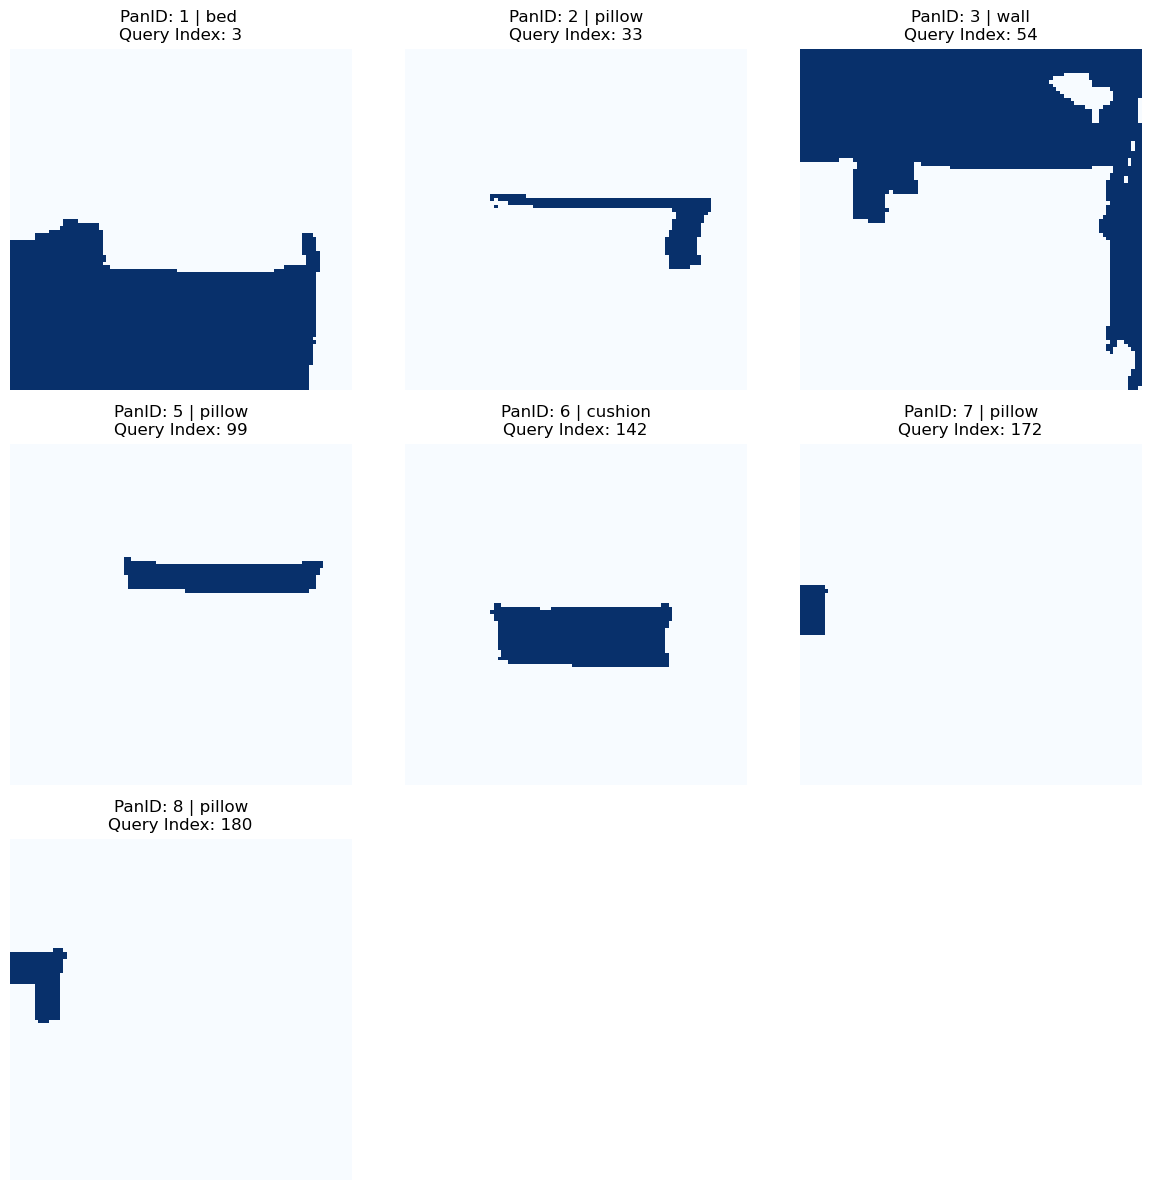

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def sync_and_plot(outputs, segments_info_subset, label_map=None):
    # 1. Extraction and Matching
    queries = outputs.transformer_decoder_last_hidden_state.squeeze(0)
    logits = outputs.class_queries_logits.squeeze(0)
    mask_logits = outputs.masks_queries_logits.squeeze(0)
    probs = F.softmax(logits, dim=-1)
    
    matched_list = []
    
    for info in segments_info_subset:
        target_label = info['label_id']
        target_score = info['score']
        
        found_idx = None
        for q_idx in range(probs.shape[0]):
            q_prob, q_label = torch.max(probs[q_idx], dim=-1)
            if q_label == target_label and torch.abs(q_prob - target_score) < 1e-4:
                found_idx = q_idx
                break
        
        if found_idx is not None:
            name = label_map[target_label] if label_map else f"ID {target_label}"
            matched_list.append({
                "pan_id": info['id'],
                "query_idx": found_idx,
                "label": name, # Fixed key name
                "mask": mask_logits[found_idx]
            })

    # 2. Plotting logic
    num_objs = len(matched_list)
    if num_objs == 0:
        print("No matches found to plot.")
        return

    cols = 3
    rows = (num_objs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten() if num_objs > 1 else [axes]

    for i, item in enumerate(matched_list):
        # Convert raw logits to a binary mask prediction
        mask_prob = torch.sigmoid(item['mask']).detach().cpu().numpy()
        binary_mask = mask_prob > 0.5 
        
        axes[i].imshow(binary_mask, cmap='Blues')
        axes[i].set_title(f"PanID: {item['pan_id']} | {item['label']}\nQuery Index: {item['query_idx']}")
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Run it on IoU-kept panoptic segments only.
kept_panoptic_ids_for_matching = {int(k) for k in best_match_for_panoptic.keys()}
segments_info_kept = [
    s for s in segments_info
    if int(s.get("id", -1)) in kept_panoptic_ids_for_matching
]
print(f"Plotting kept segments only: {len(segments_info_kept)} / {len(segments_info)}")

label_map = getattr(model.config, 'id2label', None)
sync_and_plot(outputs, segments_info_kept, label_map)

## Build Relationship Training Sample for This Frame

This section exports one training sample from the current frame:
- `queries`: shape `[200, 256]` from Mask2Former decoder queries.
- `relationship_targets`: shape `[200, 200, num_relations]`, where entries are `1` when a relation exists between two matched queries, otherwise `0`.

The output is written beside the frame image as `frame-000XXX.relation.json`.

query dim: 256
pooled pixel dim: 256
object feature dim: 512
Saved training sample: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.relation.json
object_features shape: [20, 512]
queries shape: [20, 256]
pooled_pixel_features shape: [20, 256]
relationship_targets shape: [20, 20, 41]
Top-K indices: [54, 33, 180, 99, 142, 172, 3, 68, 195, 140, 58, 113, 86, 31, 175, 151, 169, 21, 122, 149]
positive labels: 92


## Mask2Former + Relationship Branch (Frozen Backbone)

This section defines a model that freezes Mask2Former and trains only a relationship module on top of decoder queries.
It then runs a short sanity-check optimization loop on the current frame and relation targets.

In [ ]:
import json
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Load saved relation sample
# =========================
required_vars = ["image_path"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites: {missing}")

relation_json_path = image_path.replace(".color.jpg", ".relation.json")

with open(relation_json_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

# New feature: query + pooled pixel decoder feature => [20, 512]
if "object_features" not in sample:
    raise KeyError(
        "This JSON does not contain `object_features`. "
        "Run the updated feature-building cell first."
    )

object_features = torch.tensor(
    sample["object_features"],
    dtype=torch.float32,
)  # [20, 512]

relationship_targets = torch.tensor(
    sample["relationship_targets"],
    dtype=torch.float32,
)  # [20, 20, R]

print("Loaded:", relation_json_path)
print("object_features shape:", tuple(object_features.shape))
print("targets shape:", tuple(relationship_targets.shape))

# =========================
# Relation-only model
# =========================
class RelationHead(nn.Module):
    def __init__(self, hidden_dim=512, num_rel_classes=56, nhead=8,
                 num_layers=3, edge_dim=512, edge_layers=2,
                 dropout=0.2, feat_drop=0.3):
        super().__init__()
        self.input_norm = nn.LayerNorm(hidden_dim)
        self.feat_dropout = nn.Dropout(feat_drop)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nhead, dim_feedforward=1024,
            batch_first=True, dropout=dropout,
        )
        self.rel_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        pair_dim = hidden_dim * 4
        self.edge_proj = nn.Linear(pair_dim, edge_dim)

        edge_encoder_layer = nn.TransformerEncoderLayer(
            d_model=edge_dim, nhead=nhead, dim_feedforward=1024,
            batch_first=True, dropout=dropout,
        )
        self.edge_transformer = nn.TransformerEncoder(edge_encoder_layer, num_layers=edge_layers)

        self.rel_predictor = nn.Sequential(
            nn.Linear(edge_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_rel_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        x = self.feat_dropout(x)
        h = self.rel_transformer(x)
        b, k, d = h.shape
        qi = h.unsqueeze(2).expand(b, k, k, d)
        qj = h.unsqueeze(1).expand(b, k, k, d)
        edges = self.edge_proj(torch.cat([qi, qj, qi - qj, qi * qj], dim=-1))
        edges = self.edge_transformer(edges.view(b, k * k, -1))
        return self.rel_predictor(edges.view(b, k, k, -1))




class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=0.95, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        prob = torch.sigmoid(logits)

        ce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        p_t = prob * targets + (1.0 - prob) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)

        loss = alpha_t * ((1.0 - p_t) ** self.gamma) * ce
        return loss.mean()


# =========================
# Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

object_features = object_features.unsqueeze(0).to(device)       # [1, 20, 512]
target_rel = relationship_targets.unsqueeze(0).to(device)       # [1, 20, 20, R]

_, TOP_K, hidden_dim = object_features.shape
num_rel_classes = int(target_rel.shape[-1])

model = RelationHead(
    hidden_dim=hidden_dim,
    num_rel_classes=num_rel_classes,
    nhead=8,
    num_rel_layers=3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"hidden_dim: {hidden_dim}")
print(f"num_rel_classes: {num_rel_classes}")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

criterion = WeightedFocalLoss(alpha=0.95, gamma=2.0)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

# =========================
# Sanity-check training loop
# =========================
model.train()

steps = 200
threshold = 0.6

for step in range(1, steps + 1):
    optimizer.zero_grad()

    rel_logits = model(object_features)

    if rel_logits.shape != target_rel.shape:
        raise RuntimeError(
            f"Shape mismatch: rel_logits={tuple(rel_logits.shape)} "
            f"vs target={tuple(target_rel.shape)}"
        )

    loss = criterion(rel_logits, target_rel)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred_prob = torch.sigmoid(rel_logits)
        pred_bin = (pred_prob > threshold).float()

        positives = target_rel.sum().item()
        pred_positives = pred_bin.sum().item()

        tp = ((pred_bin == 1) & (target_rel == 1)).sum().item()
        fp = ((pred_bin == 1) & (target_rel == 0)).sum().item()
        fn = ((pred_bin == 0) & (target_rel == 1)).sum().item()

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        if step == 1 or step % 10 == 0:
            pos_scores = pred_prob[target_rel == 1]
            neg_scores = pred_prob[target_rel == 0]

            print(
                "Pos scores: min/max/mean =",
                pos_scores.min().item(),
                pos_scores.max().item(),
                pos_scores.mean().item(),
            )
            print(
                "Neg scores: min/max/mean =",
                neg_scores.min().item(),
                neg_scores.max().item(),
                neg_scores.mean().item(),
            )

    print(
        f"Step {step:03d}/{steps} | "
        f"loss={loss.item():.6f} | "
        f"pos={positives:.0f} | "
        f"pred_pos={pred_positives:.0f} | "
        f"P={precision:.3f} | R={recall:.3f} | F1={f1:.3f}"
    )

print("Relation-only sanity-check training loop finished.")

Loaded: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.relation.json
object_features shape: (20, 512)
targets shape: (20, 20, 41)
hidden_dim: 512
num_rel_classes: 41
Total params: 7,378,473
Trainable params: 7,378,473
Pos scores: min/max/mean = 0.29371127486228943 0.6661401987075806 0.5166352391242981
Neg scores: min/max/mean = 0.25272297859191895 0.7171682715415955 0.5138623714447021
Step 001/200 | loss=0.011371 | pos=92 | pred_pos=1906 | P=0.010 | R=0.217 | F1=0.020
Step 002/200 | loss=0.008672 | pos=92 | pred_pos=298 | P=0.027 | R=0.087 | F1=0.041
Step 003/200 | loss=0.007079 | pos=92 | pred_pos=67 | P=0.045 | R=0.033 | F1=0.038
Step 004/200 | loss=0.005738 | pos=92 | pred_pos=37 | P=0.081 | R=0.033 | F1=0.047
Step 005/200 | loss=0.004825 | pos=92 | pred_pos=13 | P=0.077 | R=0.011 | F1=0.019
Step 006/200 | loss=0.004084 | pos=92 | pred_pos=2 | P=0.500 | R=0.011 | F1=0.021
Step 007/200 | loss=0.003539 | p

Loaded: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.relation.json
object_features shape: (1, 20, 512)
Top-K old query indices: [54, 33, 180, 99, 142, 172, 3, 68, 195, 140, 58, 113, 86, 31, 175, 151, 169, 21, 122, 149]
rel_probs shape: (20, 20, 41)


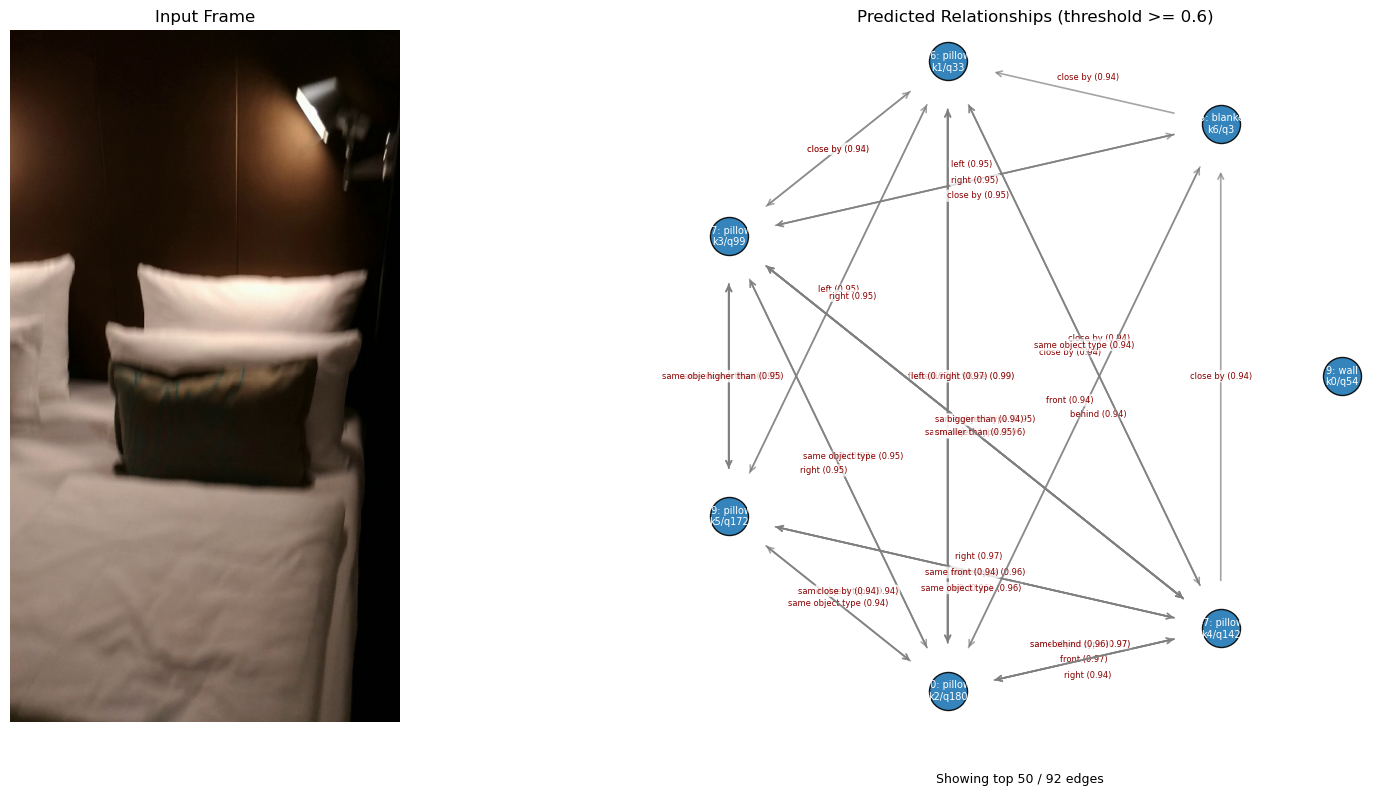

Candidate nodes before top-K filtering: 7
Candidate nodes after top-K filtering: 7
Edge selection mode: threshold >= 0.6
Selected predicted edges: 92
29:pillow (k5) --[2:left (0.997)]--> 27:pillow (k3)
27:pillow (k3) --[3:right (0.997)]--> 29:pillow (k5)
26:pillow (k1) --[32:same object type (0.994)]--> 30:pillow (k2)
30:pillow (k2) --[32:same object type (0.994)]--> 26:pillow (k1)
27:pillow (k3) --[32:same object type (0.993)]--> 29:pillow (k5)
29:pillow (k5) --[32:same object type (0.993)]--> 27:pillow (k3)
26:pillow (k1) --[4:front (0.986)]--> 30:pillow (k2)
30:pillow (k2) --[5:behind (0.985)]--> 26:pillow (k1)
30:pillow (k2) --[2:left (0.975)]--> 26:pillow (k1)
47:pillow (k4) --[32:same object type (0.974)]--> 30:pillow (k2)
47:pillow (k4) --[2:left (0.973)]--> 27:pillow (k3)
26:pillow (k1) --[3:right (0.969)]--> 30:pillow (k2)
30:pillow (k2) --[2:left (0.968)]--> 27:pillow (k3)
47:pillow (k4) --[4:front (0.968)]--> 30:pillow (k2)
30:pillow (k2) --[32:same object type (0.967)]--> 4

In [12]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

required_vars = ["model", "image", "image_path", "best_match_for_panoptic"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites: {missing}. Run previous cells first.")

device = next(model.parameters()).device
model.eval()

# =========================
# Load saved relation JSON
# =========================
relation_json_path = image_path.replace(".color.jpg", ".relation.json")

with open(relation_json_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

if "object_features" not in sample:
    raise KeyError(
        "This JSON does not contain `object_features`. "
        "Run the updated query + pooled pixel feature extraction cell first."
    )

object_features = torch.tensor(
    sample["object_features"],
    dtype=torch.float32,
).unsqueeze(0).to(device)  # [1, 20, 512]

topk_indices = sample["metadata"]["topk_indices"]

old_query_to_topk = {
    int(old_q): int(new_q)
    for new_q, old_q in enumerate(topk_indices)
}

print("Loaded:", relation_json_path)
print("object_features shape:", tuple(object_features.shape))
print("Top-K old query indices:", topk_indices)

# =========================
# Relation inference only
# =========================
with torch.inference_mode():
    rel_logits = model(object_features)  # [1, 20, 20, R]
    rel_probs = torch.sigmoid(rel_logits)[0].detach().cpu().numpy()

print("rel_probs shape:", rel_probs.shape)

# =========================
# Load names
# =========================
scan_id = Path(image_path).parents[1].name

objects_json_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/objects.json"
relationships_json_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json"
relation_names_path = str(Path(relationships_json_path).with_name("relationships.txt"))

with open(relation_names_path, "r", encoding="utf-8") as f:
    relation_names = [line.strip() for line in f if line.strip()]

with open(objects_json_path, "r", encoding="utf-8") as f:
    objects_data = json.load(f)

scan_objects_entry = next(
    (entry for entry in objects_data.get("scans", []) if entry.get("scan") == scan_id),
    None,
)

object_name_by_id = {}

if scan_objects_entry is not None:
    for obj in scan_objects_entry.get("objects", []):
        try:
            obj_id = int(obj.get("id"))
        except (TypeError, ValueError):
            continue

        object_name_by_id[obj_id] = obj.get("label", f"obj_{obj_id}")

# =========================
# Candidate objects
# =========================
kept_rendered_ids = {
    int(match_info["rendered_instance_id"])
    for match_info in best_match_for_panoptic.values()
}

visibility_path = image_path.replace(".color.jpg", ".visibility.txt")
visible_object_ids = set()

if Path(visibility_path).exists():
    with open(visibility_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()

            if not parts:
                continue

            try:
                visible_object_ids.add(int(parts[0]))
            except ValueError:
                continue

if len(visible_object_ids) > 0:
    candidate_object_ids = kept_rendered_ids.intersection(visible_object_ids)
else:
    candidate_object_ids = set(kept_rendered_ids)

# =========================
# Rendered object -> top-K feature index
# =========================
rendered_to_panoptic = {
    int(info["rendered_instance_id"]): int(pan_id)
    for pan_id, info in best_match_for_panoptic.items()
}

if "matched_list" in globals() and matched_list is not None:
    panoptic_to_query = {
        int(item["pan_id"]): int(item["query_idx"])
        for item in matched_list
    }
else:
    panoptic_to_query = {}

rendered_to_query = {}

for rid in candidate_object_ids:
    pan_id = rendered_to_panoptic.get(int(rid))

    if pan_id is None:
        continue

    old_qid = panoptic_to_query.get(int(pan_id))

    if old_qid is None:
        continue

    new_qid = old_query_to_topk.get(int(old_qid))

    if new_qid is not None:
        rendered_to_query[int(rid)] = int(new_qid)

sorted_nodes = sorted(rendered_to_query.keys())

# =========================
# Predict relation edges
# =========================
relationship_threshold = 0.6
top_k_fallback = 10

all_scored_edges = []

for src_id in sorted_nodes:
    src_q = rendered_to_query.get(int(src_id))

    if src_q is None:
        continue

    for dst_id in sorted_nodes:
        if src_id == dst_id:
            continue

        dst_q = rendered_to_query.get(int(dst_id))

        if dst_q is None:
            continue

        # Multi-label relation prediction:
        # keep every relation above threshold, not just argmax.
        for rel_id in range(rel_probs.shape[-1]):
            rel_score = float(rel_probs[src_q, dst_q, rel_id])

            rel_name = (
                relation_names[rel_id]
                if 0 <= rel_id < len(relation_names)
                else f"rel_{rel_id}"
            )

            all_scored_edges.append(
                (int(src_id), int(dst_id), rel_id, rel_name, rel_score)
            )

predicted_relationships = [
    edge for edge in all_scored_edges
    if edge[4] >= relationship_threshold
]

selection_mode = f"threshold >= {relationship_threshold}"

if len(predicted_relationships) == 0 and len(all_scored_edges) > 0:
    predicted_relationships = sorted(
        all_scored_edges,
        key=lambda x: x[4],
        reverse=True,
    )[:top_k_fallback]

    selection_mode = f"top-{len(predicted_relationships)} fallback"

# Sort final edges by confidence
predicted_relationships = sorted(
    predicted_relationships,
    key=lambda x: x[4],
    reverse=True,
)

# =========================
# Visualization
# =========================
if len(sorted_nodes) == 0:
    print("No candidate objects survived top-K feature filtering.")
else:
    n = len(sorted_nodes)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    radius = 1.0

    node_pos = {
        node_id: np.array(
            [radius * np.cos(angle), radius * np.sin(angle)],
            dtype=np.float32,
        )
        for node_id, angle in zip(sorted_nodes, angles)
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].imshow(image)
    axes[0].set_title("Input Frame")
    axes[0].axis("off")

    ax = axes[1]
    ax.set_title(f"Predicted Relationships ({selection_mode})")

    for node_id in sorted_nodes:
        x, y = node_pos[node_id]
        label_name = object_name_by_id.get(node_id, f"obj_{node_id}")
        topk_id = rendered_to_query.get(node_id, -1)
        old_query_id = topk_indices[topk_id] if 0 <= topk_id < len(topk_indices) else "?"

        ax.scatter(
            x,
            y,
            s=750,
            c="tab:blue",
            alpha=0.9,
            edgecolors="black",
        )

        ax.text(
            x,
            y,
            f"{node_id}: {label_name}\nk{topk_id}/q{old_query_id}",
            ha="center",
            va="center",
            color="white",
            fontsize=7,
        )

    # Draw only top edges to keep graph readable
    max_draw_edges = 50
    draw_edges = predicted_relationships[:max_draw_edges]

    for idx, (src_id, dst_id, _, rel_name, rel_score) in enumerate(draw_edges):
        src = node_pos[src_id]
        dst = node_pos[dst_id]

        vec = dst - src
        norm = np.linalg.norm(vec)

        if norm < 1e-8:
            continue

        unit = vec / norm
        start = src + unit * 0.14
        end = dst - unit * 0.14

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(
                arrowstyle="->",
                lw=1.2,
                color="tab:gray",
                alpha=0.7,
            ),
        )

        mid = (start + end) * 0.5
        perp = np.array([-unit[1], unit[0]], dtype=np.float32)
        offset = ((idx % 3) - 1) * 0.05
        text_pos = mid + perp * offset

        ax.text(
            text_pos[0],
            text_pos[1],
            f"{rel_name} ({rel_score:.2f})",
            fontsize=6,
            color="darkred",
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.75,
                edgecolor="none",
            ),
        )

    if len(predicted_relationships) == 0:
        ax.text(
            0.0,
            0.0,
            "No predicted edges available",
            ha="center",
            va="center",
            fontsize=10,
            color="tab:red",
        )

    if len(predicted_relationships) > max_draw_edges:
        ax.text(
            0.0,
            -1.25,
            f"Showing top {max_draw_edges} / {len(predicted_relationships)} edges",
            ha="center",
            va="center",
            fontsize=9,
            color="black",
        )

    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# =========================
# Print results
# =========================
print(f"Candidate nodes before top-K filtering: {len(candidate_object_ids)}")
print(f"Candidate nodes after top-K filtering: {len(sorted_nodes)}")
print(f"Edge selection mode: {selection_mode}")
print(f"Selected predicted edges: {len(predicted_relationships)}")

for src_id, dst_id, rel_id, rel_name, rel_score in predicted_relationships[:50]:
    src_name = object_name_by_id.get(src_id, f"obj_{src_id}")
    dst_name = object_name_by_id.get(dst_id, f"obj_{dst_id}")

    src_k = rendered_to_query.get(src_id, "?")
    dst_k = rendered_to_query.get(dst_id, "?")

    print(
        f"{src_id}:{src_name} "
        f"(k{src_k}) --[{rel_id}:{rel_name} ({rel_score:.3f})]--> "
        f"{dst_id}:{dst_name} (k{dst_k})"
    )

## Build Relation JSON Dataset For All Frames

This section iterates over every frame in one sequence and writes one `.relation.json` file per frame for training.

In [13]:
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
from tqdm import tqdm
from transformers.utils import logging

logging.set_verbosity_error()

# -------- Config --------
scans_root = Path("/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans")

relationships_json_path = Path(
    "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json"
)
relationship_names_path = relationships_json_path.with_name("relationships.txt")

model_name = checkpoint if "checkpoint" in globals() else "facebook/mask2former-swin-large-ade-panoptic"

TOP_K = 20
iou_threshold = 0.3
use_visibility_filter_for_targets = False
max_scans = None
max_frames_per_scan = None
overwrite_existing = True  # set True to regenerate files with query_to_object_id
# -----------------------

if not scans_root.exists():
    raise FileNotFoundError(f"Scans root not found: {scans_root}")
if not relationships_json_path.exists():
    raise FileNotFoundError(f"Missing relationships.json: {relationships_json_path}")
if not relationship_names_path.exists():
    raise FileNotFoundError(f"Missing relationships.txt: {relationship_names_path}")

with open(relationships_json_path, "r", encoding="utf-8") as f:
    relationships_data = json.load(f)

with open(relationship_names_path, "r", encoding="utf-8") as f:
    relation_names = [line.strip() for line in f if line.strip()]

relationships_by_scan = {
    entry.get("scan"): entry
    for entry in relationships_data.get("scans", [])
    if entry.get("scan") is not None
}


def align_to_reference_orientation(img, reference_size):
    if img.size == reference_size:
        return img

    for angle in (-90, 90, 180):
        candidate = img.rotate(angle, expand=True)
        if candidate.size == reference_size:
            return candidate

    return img


def decode_rendered_instances(instances_img):
    arr = np.array(instances_img, dtype=np.uint8)

    if arr.ndim == 3:
        if (
            np.array_equal(arr[..., 0], arr[..., 1])
            and np.array_equal(arr[..., 1], arr[..., 2])
        ):
            return arr[..., 0].astype(np.int32)

        return (
            arr[..., 0].astype(np.int32)
            + (arr[..., 1].astype(np.int32) << 8)
            + (arr[..., 2].astype(np.int32) << 16)
        )

    return arr.astype(np.int32)


def map_panoptic_segment_to_query(outputs, segments_info_subset):
    logits = outputs.class_queries_logits.squeeze(0)
    probs = F.softmax(logits, dim=-1)

    used_query_indices = set()
    seg_id_to_query_idx = {}

    for seg in segments_info_subset:
        seg_id = int(seg["id"])
        label_id = int(seg["label_id"])
        score = float(seg["score"])

        label_scores = probs[:, label_id]

        found_idx = None
        candidates = torch.where(torch.abs(label_scores - score) < 1e-4)[0].tolist()

        for idx in candidates:
            if idx not in used_query_indices:
                found_idx = idx
                break

        if found_idx is None:
            ranked = torch.argsort(label_scores, descending=True).tolist()
            for idx in ranked:
                if idx not in used_query_indices:
                    found_idx = idx
                    break

        if found_idx is not None:
            used_query_indices.add(found_idx)
            seg_id_to_query_idx[seg_id] = int(found_idx)

    return seg_id_to_query_idx


def best_iou_matches_vectorized(
    predicted_panoptic_map,
    rendered_instance_ids,
    panoptic_ids,
    rendered_ids,
    threshold,
):
    if len(panoptic_ids) == 0 or len(rendered_ids) == 0:
        return {}

    panoptic_ids_arr = np.asarray(panoptic_ids, dtype=np.int64)
    rendered_ids_arr = np.asarray(rendered_ids, dtype=np.int64)

    pan_idx_map = {int(pid): i for i, pid in enumerate(panoptic_ids_arr.tolist())}
    rend_idx_map = {int(rid): i for i, rid in enumerate(rendered_ids_arr.tolist())}

    pan_areas = np.array(
        [(predicted_panoptic_map == pid).sum() for pid in panoptic_ids_arr],
        dtype=np.int64,
    )

    rend_areas = np.array(
        [(rendered_instance_ids == rid).sum() for rid in rendered_ids_arr],
        dtype=np.int64,
    )

    valid_pan = np.isin(predicted_panoptic_map, panoptic_ids_arr)
    valid_rend = np.isin(rendered_instance_ids, rendered_ids_arr)
    valid = valid_pan & valid_rend

    pan_vals = predicted_panoptic_map[valid].astype(np.int64)
    rend_vals = rendered_instance_ids[valid].astype(np.int64)

    if pan_vals.size == 0:
        return {}

    pan_idx = np.array([pan_idx_map[int(v)] for v in pan_vals], dtype=np.int64)
    rend_idx = np.array([rend_idx_map[int(v)] for v in rend_vals], dtype=np.int64)

    intersections = np.zeros(
        (len(panoptic_ids_arr), len(rendered_ids_arr)),
        dtype=np.int64,
    )

    np.add.at(intersections, (pan_idx, rend_idx), 1)

    unions = pan_areas[:, None] + rend_areas[None, :] - intersections
    iou_matrix = intersections / np.maximum(unions, 1)

    best_rend_indices = np.argmax(iou_matrix, axis=1)
    best_ious = iou_matrix[np.arange(iou_matrix.shape[0]), best_rend_indices]

    best_match_for_panoptic = {}

    for i, pan_id in enumerate(panoptic_ids_arr.tolist()):
        best_iou = float(best_ious[i])

        if best_iou > threshold:
            best_rid = int(rendered_ids_arr[int(best_rend_indices[i])])
            best_match_for_panoptic[int(pan_id)] = {
                "rendered_instance_id": best_rid,
                "iou": best_iou,
            }

    return best_match_for_panoptic


def get_pixel_decoder_features(outputs):
    if (
        hasattr(outputs, "pixel_decoder_last_hidden_state")
        and outputs.pixel_decoder_last_hidden_state is not None
    ):
        return outputs.pixel_decoder_last_hidden_state

    if (
        hasattr(outputs, "pixel_decoder_hidden_states")
        and outputs.pixel_decoder_hidden_states is not None
    ):
        return outputs.pixel_decoder_hidden_states[-1]

    raise RuntimeError(
        "Pixel decoder features not found. "
        "Run Mask2Former with output_hidden_states=True."
    )


def mask_pool_pixel_features(pixel_features, mask_logits):
    if mask_logits.shape[-2:] != pixel_features.shape[-2:]:
        mask_logits = F.interpolate(
            mask_logits,
            size=pixel_features.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    masks = torch.sigmoid(mask_logits)
    masks = masks / (masks.sum(dim=(2, 3), keepdim=True) + 1e-6)

    pooled = torch.einsum("bchw,bnhw->bnc", pixel_features, masks)
    return pooled.squeeze(0)


def select_topk_object_features(outputs, top_k):
    logits = outputs.class_queries_logits.squeeze(0)
    probs = F.softmax(logits, dim=-1)

    scores = probs[:, :-1].max(dim=1).values

    k = min(top_k, scores.shape[0])
    topk = torch.topk(scores, k=k)

    topk_indices = topk.indices.detach().cpu().tolist()
    topk_scores = topk.values.detach().cpu().tolist()

    old_to_new = {
        int(old_idx): int(new_idx)
        for new_idx, old_idx in enumerate(topk_indices)
    }

    queries_full = outputs.transformer_decoder_last_hidden_state.squeeze(0).detach()
    queries_topk = queries_full[topk.indices]

    pixel_features = get_pixel_decoder_features(outputs).detach()
    mask_logits = outputs.masks_queries_logits.detach()

    pooled_full = mask_pool_pixel_features(
        pixel_features=pixel_features,
        mask_logits=mask_logits,
    )

    pooled_topk = pooled_full[topk.indices]

    object_features = torch.cat(
        [queries_topk.cpu(), pooled_topk.cpu()],
        dim=-1,
    )

    return (
        object_features,
        queries_topk.cpu(),
        pooled_topk.cpu(),
        topk_indices,
        topk_scores,
        old_to_new,
    )


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor_ds = AutoImageProcessor.from_pretrained(model_name)
model_ds = Mask2FormerForUniversalSegmentation.from_pretrained(model_name).to(device)
model_ds.eval()

scan_dirs = sorted([p for p in scans_root.iterdir() if p.is_dir()])

if max_scans is not None:
    scan_dirs = scan_dirs[:max_scans]

global_index = {
    "scans_root": str(scans_root),
    "top_k": TOP_K,
    "iou_threshold": iou_threshold,
    "feature_type": "query_plus_mask_pooled_pixel_decoder",
    "use_visibility_filter_for_targets": use_visibility_filter_for_targets,
    "items": [],
}

total_generated = 0
total_skipped = 0
total_scans_done = 0

for scan_dir in tqdm(scan_dirs, desc="Scans"):
    scan_id = scan_dir.name
    sequence_dir = scan_dir / "sequence"

    if not sequence_dir.exists():
        total_skipped += 1
        continue

    scan_relationships_entry = relationships_by_scan.get(scan_id)
    if scan_relationships_entry is None:
        print(f"[skip scan] {scan_id}: not found in relationships.json")
        total_skipped += 1
        continue

    all_color_frames = sorted(sequence_dir.glob("frame-*.color.jpg"))
    frame_paths = [p for p in all_color_frames if ".rendered." not in p.name]

    if max_frames_per_scan is not None:
        frame_paths = frame_paths[:max_frames_per_scan]

    if len(frame_paths) == 0:
        print(f"[skip scan] {scan_id}: no frames")
        total_skipped += 1
        continue

    generated = 0
    skipped = 0
    dataset_index = []

    for frame_path in tqdm(frame_paths, desc=f"{scan_id}", leave=False):
        out_path = Path(str(frame_path).replace(".color.jpg", ".relation.json"))

        if out_path.exists() and not overwrite_existing:
            skipped += 1
            continue

        instances_path = Path(str(frame_path).replace(".color.jpg", ".rendered.instances.png"))
        visibility_path = Path(str(frame_path).replace(".color.jpg", ".visibility.txt"))

        if not instances_path.exists():
            skipped += 1
            continue

        try:
            image = Image.open(frame_path).convert("RGB").rotate(-90, expand=True)

            rendered_instances = Image.open(instances_path).convert("RGB")
            rendered_instances = align_to_reference_orientation(rendered_instances, image.size)
            rendered_instance_ids = decode_rendered_instances(rendered_instances)

            inputs_ds = processor_ds(images=image, return_tensors="pt")
            inputs_ds = {k: v.to(device) for k, v in inputs_ds.items()}

            with torch.inference_mode():
                outputs_ds = model_ds(
                    **inputs_ds,
                    output_hidden_states=True,
                )

                panoptic = processor_ds.post_process_panoptic_segmentation(
                    outputs_ds,
                    target_sizes=[image.size[::-1]],
                    threshold=0.3,
                    mask_threshold=0.3,
                    overlap_mask_area_threshold=0.7,
                )[0]

            predicted_panoptic_map = panoptic["segmentation"].cpu().numpy()
            segments_info = panoptic["segments_info"]

            panoptic_ids = [
                int(x)
                for x in np.unique(predicted_panoptic_map)
                if int(x) != 0
            ]

            rendered_ids = [
                int(x)
                for x in np.unique(rendered_instance_ids)
                if int(x) != 0
            ]

            best_match_for_panoptic = best_iou_matches_vectorized(
                predicted_panoptic_map=predicted_panoptic_map,
                rendered_instance_ids=rendered_instance_ids,
                panoptic_ids=panoptic_ids,
                rendered_ids=rendered_ids,
                threshold=iou_threshold,
            )

            kept_panoptic_ids = set(best_match_for_panoptic.keys())

            segments_info_kept = [
                s for s in segments_info
                if int(s.get("id", -1)) in kept_panoptic_ids
            ]

            seg_id_to_query_idx_full = map_panoptic_segment_to_query(
                outputs_ds,
                segments_info_kept,
            )

            (
                object_features,
                queries_tensor,
                pooled_pixel_features,
                topk_indices,
                topk_scores,
                old_to_new,
            ) = select_topk_object_features(outputs_ds, TOP_K)

            num_queries = int(object_features.shape[0])
            object_feature_dim = int(object_features.shape[1])
            query_dim = int(queries_tensor.shape[1])
            pooled_pixel_dim = int(pooled_pixel_features.shape[1])
            num_relations = len(relation_names)

            seg_id_to_query_idx = {
                int(seg_id): int(old_to_new[old_q])
                for seg_id, old_q in seg_id_to_query_idx_full.items()
                if int(old_q) in old_to_new
            }

            rendered_to_panoptic = {}

            for pan_id, match_info in best_match_for_panoptic.items():
                pan_id = int(pan_id)

                if pan_id not in seg_id_to_query_idx:
                    continue

                rendered_id = int(match_info["rendered_instance_id"])
                iou = float(match_info["iou"])

                if (
                    rendered_id not in rendered_to_panoptic
                    or iou > rendered_to_panoptic[rendered_id]["iou"]
                ):
                    rendered_to_panoptic[rendered_id] = {
                        "pan_id": pan_id,
                        "iou": iou,
                    }

            kept_rendered_ids = set(rendered_to_panoptic.keys())

            visible_object_ids = set()

            if visibility_path.exists():
                with open(visibility_path, "r", encoding="utf-8") as f:
                    for line in f:
                        parts = line.strip().split()

                        if not parts:
                            continue

                        try:
                            visible_object_ids.add(int(parts[0]))
                        except ValueError:
                            pass

            if use_visibility_filter_for_targets and len(visible_object_ids) > 0:
                candidate_rendered_ids = kept_rendered_ids.intersection(visible_object_ids)
            else:
                candidate_rendered_ids = set(kept_rendered_ids)

            relationship_targets = np.zeros(
                (num_queries, num_queries, num_relations),
                dtype=np.uint8,
            )

            # IMPORTANT:
            # query_to_object_id[q] stores the global 3RScan/3DSSG object id.
            # This is the id used by relationships.json.
            query_to_object_id = [-1 for _ in range(num_queries)]

            for rendered_id, info in rendered_to_panoptic.items():
                pan_id = int(info["pan_id"])
                q = seg_id_to_query_idx.get(pan_id)

                if q is None:
                    continue

                if int(q) < 0 or int(q) >= num_queries:
                    continue

                scan_object_id = int(rendered_id)
                query_to_object_id[int(q)] = scan_object_id

            used_edges = 0
            skipped_non_candidate = 0
            skipped_unmapped = 0
            skipped_rel_out_of_range = 0

            for rel in scan_relationships_entry.get("relationships", []):
                if not isinstance(rel, (list, tuple)) or len(rel) < 3:
                    continue

                try:
                    src_object_id = int(rel[0])
                    dst_object_id = int(rel[1])
                    rel_id = int(rel[2])
                except (TypeError, ValueError):
                    continue

                if rel_id < 0 or rel_id >= num_relations:
                    skipped_rel_out_of_range += 1
                    continue

                if (
                    src_object_id not in candidate_rendered_ids
                    or dst_object_id not in candidate_rendered_ids
                ):
                    skipped_non_candidate += 1
                    continue

                src_info = rendered_to_panoptic.get(src_object_id)
                dst_info = rendered_to_panoptic.get(dst_object_id)

                if src_info is None or dst_info is None:
                    skipped_unmapped += 1
                    continue

                src_pan = int(src_info["pan_id"])
                dst_pan = int(dst_info["pan_id"])

                src_q = seg_id_to_query_idx.get(src_pan)
                dst_q = seg_id_to_query_idx.get(dst_pan)

                if src_q is None or dst_q is None:
                    skipped_unmapped += 1
                    continue

                relationship_targets[src_q, dst_q, rel_id] = 1
                used_edges += 1

            sample = {
                "frame_id": frame_path.name.replace(".color.jpg", ""),
                "scan_id": scan_id,
                "image_path": str(frame_path),

                "object_feature_shape": [num_queries, object_feature_dim],
                "query_shape": [num_queries, query_dim],
                "pooled_pixel_feature_shape": [num_queries, pooled_pixel_dim],
                "relationship_shape": [num_queries, num_queries, num_relations],

                "relation_names": relation_names,
                "relation_names_path": str(relationship_names_path),

                "object_features": object_features.numpy().tolist(),
                "queries": queries_tensor.numpy().tolist(),
                "pooled_pixel_features": pooled_pixel_features.numpy().tolist(),

                "relationship_targets": relationship_targets.tolist(),

                # NEW: query index -> global scan object id
                "query_to_object_id": query_to_object_id,

                "metadata": {
                    "top_k": TOP_K,
                    "topk_indices": topk_indices,
                    "topk_scores": topk_scores,

                    "feature_type": "query_plus_mask_pooled_pixel_decoder",
                    "object_feature_dim": object_feature_dim,
                    "query_dim": query_dim,
                    "pooled_pixel_dim": pooled_pixel_dim,

                    "num_segments_info_total": len(segments_info),
                    "num_segments_info_kept_iou": len(segments_info_kept),
                    "num_segments_survived_topk": len(seg_id_to_query_idx),

                    "num_kept_rendered_ids": len(kept_rendered_ids),
                    "num_candidate_rendered_ids": len(candidate_rendered_ids),

                    "num_queries_mapped_to_scan_objects": int(sum(x >= 0 for x in query_to_object_id)),

                    "num_positive_edges": int(relationship_targets.sum()),
                    "num_relationship_records_used": used_edges,
                    "num_relationship_records_skipped_non_candidate": skipped_non_candidate,
                    "num_relationship_records_skipped_unmapped": skipped_unmapped,
                    "num_relationship_records_skipped_rel_out_of_range": skipped_rel_out_of_range,

                    "iou_threshold": iou_threshold,
                    "use_visibility_filter_for_targets": use_visibility_filter_for_targets,
                },
            }

            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(sample, f)

            generated += 1
            total_generated += 1

            dataset_index.append({
                "frame": frame_path.name,
                "relation_json": out_path.name,
                "object_feature_shape": sample["object_feature_shape"],
                "query_shape": sample["query_shape"],
                "pooled_pixel_feature_shape": sample["pooled_pixel_feature_shape"],
                "relationship_shape": sample["relationship_shape"],
                "topk_indices": topk_indices,
                "query_to_object_id": query_to_object_id,
                "num_queries_mapped_to_scan_objects": int(sum(x >= 0 for x in query_to_object_id)),
                "num_positive_edges": int(sample["metadata"]["num_positive_edges"]),
                "num_segments_survived_topk": int(sample["metadata"]["num_segments_survived_topk"]),
            })

        except Exception as e:
            skipped += 1
            total_skipped += 1
            print(f"[skip frame] {scan_id}/{frame_path.name}: {e}")

    index_path = sequence_dir / "relation_dataset_index.json"

    with open(index_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "scan_id": scan_id,
                "sequence_dir": str(sequence_dir),
                "num_frames_scanned": len(frame_paths),
                "num_generated": generated,
                "num_skipped": skipped,
                "top_k": TOP_K,
                "iou_threshold": iou_threshold,
                "feature_type": "query_plus_mask_pooled_pixel_decoder",
                "use_visibility_filter_for_targets": use_visibility_filter_for_targets,
                "items": dataset_index,
            },
            f,
            indent=2,
        )

    global_index["items"].append({
        "scan_id": scan_id,
        "sequence_dir": str(sequence_dir),
        "num_frames_scanned": len(frame_paths),
        "num_generated": generated,
        "num_skipped": skipped,
        "index_path": str(index_path),
    })

    total_scans_done += 1

global_index_path = scans_root / "relation_dataset_global_index.json"

with open(global_index_path, "w", encoding="utf-8") as f:
    json.dump(global_index, f, indent=2)

print("\nDone building top-K relation dataset for all scans.")
print("Feature type: query + mask-pooled pixel decoder")
print(f"Scans processed: {total_scans_done}")
print(f"Generated .relation.json files: {total_generated}")
print(f"Skipped: {total_skipped}")
print(f"Global index: {global_index_path}")

Scans:  96%|█████████▋| 27/28 [40:07<01:13, 73.58s/it]  

[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000000.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000000.color.jpg'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000001.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000001.color.jpg'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000002.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000002.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000003.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000003.color.jpg'
[skip frame] 0cac75ca-8d6f-

[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000031.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000031.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000032.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000032.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000033.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000033.color.jpg'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000034.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000034.rendered.instances.png'
[

Scans: 100%|██████████| 28/28 [40:08<00:00, 86.01s/it]

[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000053.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000053.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000054.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000054.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000055.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000055.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000056.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000056.rendered.ins

## Full Training On Generated Relation JSON Dataset

This section trains the relationship branch on all generated relation JSON files.

In [50]:
import json
from pathlib import Path
import random
import numpy as np
import torch
from torch.utils.data import Dataset
from tqdm import tqdm
from collections import defaultdict

# -------- Config --------
scans_root = Path("/home/station2/Zermat/RTSGS-SLAM/Datasets/3Rscan/3RScan/data/scans")
train_glob = "**/sequence/frame-*.relation.json"

train_ratio = 0.9
seed = 42

# If you have names, replace this later
rel_names = None

# Optional: exclude frames with zero relations
exclude_zero_relation_frames = False
# ------------------------


class RelationJsonDataset(Dataset):
    def __init__(self, json_paths, desc="Loading relation JSONs"):
        self.valid_json_paths = []
        self.invalid_json_paths = []

        self.total_positives = 0
        self.total_negatives = 0
        self.per_relation_positives = None

        self.hidden_dim = None
        self.num_rel_classes = None

        for p in tqdm(sorted(json_paths), desc=desc, unit="file"):
            try:
                with open(p, "r", encoding="utf-8") as f:
                    sample = json.load(f)

                if "object_features" not in sample:
                    raise KeyError("missing object_features")

                if "relationship_targets" not in sample:
                    raise KeyError("missing relationship_targets")

                object_features = np.asarray(sample["object_features"], dtype=np.float32)
                targets = np.asarray(sample["relationship_targets"], dtype=np.float32)

                if object_features.ndim != 2:
                    raise ValueError(f"object_features must be [K,D], got {object_features.shape}")

                if targets.ndim != 3:
                    raise ValueError(f"relationship_targets must be [K,K,R], got {targets.shape}")

                if object_features.shape[0] != targets.shape[0] or targets.shape[0] != targets.shape[1]:
                    raise ValueError(
                        f"K mismatch: object_features={object_features.shape}, targets={targets.shape}"
                    )

                if self.hidden_dim is None:
                    self.hidden_dim = int(object_features.shape[-1])
                    self.num_rel_classes = int(targets.shape[-1])
                    self.per_relation_positives = np.zeros(self.num_rel_classes, dtype=np.int64)

                if object_features.shape[-1] != self.hidden_dim:
                    raise ValueError(f"hidden_dim mismatch: expected {self.hidden_dim}, got {object_features.shape[-1]}")

                if targets.shape[-1] != self.num_rel_classes:
                    raise ValueError(f"num_rel_classes mismatch: expected {self.num_rel_classes}, got {targets.shape[-1]}")

                pos = int(targets.sum())

                if exclude_zero_relation_frames and pos == 0:
                    raise ValueError("zero-relation frame")

                total_labels = int(targets.size)
                neg = total_labels - pos

                self.total_positives += pos
                self.total_negatives += neg
                self.per_relation_positives += targets.sum(axis=(0, 1)).astype(np.int64)

                self.valid_json_paths.append(p)

            except Exception as e:
                self.invalid_json_paths.append((p, str(e)))

        if not self.valid_json_paths:
            raise RuntimeError("No valid relation json files found.")

    def __len__(self):
        return len(self.valid_json_paths)

    def __getitem__(self, idx):
        p = self.valid_json_paths[idx]

        with open(p, "r", encoding="utf-8") as f:
            sample = json.load(f)

        object_features = torch.tensor(sample["object_features"], dtype=torch.float32)
        targets = torch.tensor(sample["relationship_targets"], dtype=torch.float32)

        return object_features, targets


def get_scene_id(path: Path):
    # expected:
    # scans_root / scene_id / sequence / frame-xxxx.relation.json
    return path.parent.parent.name


def print_dataset_stats(name, dataset):
    print(f"\n========== {name} stats ==========")
    print(f"Frames: {len(dataset):,}")
    print(f"Invalid skipped: {len(dataset.invalid_json_paths):,}")
    print(f"hidden_dim: {dataset.hidden_dim}")
    print(f"num_rel_classes: {dataset.num_rel_classes}")
    print(f"Total positives: {dataset.total_positives:,}")
    print(f"Total negatives: {dataset.total_negatives:,}")

    total = dataset.total_positives + dataset.total_negatives
    pos_rate = dataset.total_positives / max(1, total)
    neg_rate = dataset.total_negatives / max(1, total)

    print(f"Positive rate: {pos_rate:.10f}")
    print(f"Negative rate: {neg_rate:.10f}")

    print("\nPer-relation positives:")
    names = rel_names
    if names is None:
        names = [f"rel_{i}" for i in range(dataset.num_rel_classes)]

    for i, count in enumerate(dataset.per_relation_positives):
        print(f"{i:02d} | {names[i]:>20} | {int(count):,}")


# =========================
# Find files
# =========================
json_paths = sorted(scans_root.glob(train_glob))

print(f"Searching in: {scans_root}")
print(f"Found relation JSONs: {len(json_paths):,}")

# =========================
# Split by scene
# =========================
scene_to_paths = defaultdict(list)

for p in json_paths:
    scene_to_paths[get_scene_id(p)].append(p)

scene_ids = sorted(scene_to_paths.keys())

random.seed(seed)
random.shuffle(scene_ids)

train_scene_count = max(1, int(len(scene_ids) * train_ratio))
val_scene_count = len(scene_ids) - train_scene_count

if val_scene_count == 0 and len(scene_ids) > 1:
    val_scene_count = 1
    train_scene_count = len(scene_ids) - 1

train_scenes = set(scene_ids[:train_scene_count])
val_scenes = set(scene_ids[train_scene_count:])

train_paths = []
val_paths = []

for scene_id, paths in scene_to_paths.items():
    if scene_id in train_scenes:
        train_paths.extend(paths)
    else:
        val_paths.extend(paths)

print(f"\nTotal scenes: {len(scene_ids):,}")
print(f"Train scenes: {len(train_scenes):,}")
print(f"Val scenes: {len(val_scenes):,}")
print(f"Train JSONs before validation: {len(train_paths):,}")
print(f"Val JSONs before validation: {len(val_paths):,}")

# =========================
# Create datasets
# =========================
train_dataset = RelationJsonDataset(train_paths, desc="Loading train JSONs")
val_dataset = RelationJsonDataset(val_paths, desc="Loading val JSONs")

hidden_dim = train_dataset.hidden_dim
num_rel_classes = train_dataset.num_rel_classes

if val_dataset.hidden_dim != hidden_dim:
    raise RuntimeError("Validation hidden_dim does not match train hidden_dim")

if val_dataset.num_rel_classes != num_rel_classes:
    raise RuntimeError("Validation num_rel_classes does not match train num_rel_classes")

print_dataset_stats("TRAIN", train_dataset)
print_dataset_stats("VAL", val_dataset)

print("\nScene split ready.")

Searching in: /home/station2/Zermat/RTSGS-SLAM/Datasets/3Rscan/3RScan/data/scans
Found relation JSONs: 33,957

Total scenes: 173
Train scenes: 155
Val scenes: 18
Train JSONs before validation: 29,926
Val JSONs before validation: 4,031


Loading val JSONs: 100%|██████████| 4031/4031 [00:24<00:00, 167.45file/s]


========== TRAIN stats ==========
Frames: 29,884
Invalid skipped: 42
hidden_dim: 512
num_rel_classes: 41
Total positives: 272,181
Total negatives: 489,825,419
Positive rate: 0.0005553608
Negative rate: 0.9994446392

Per-relation positives:
00 |                rel_0 | 0
01 |                rel_1 | 1,064
02 |                rel_2 | 18,233
03 |                rel_3 | 18,233
04 |                rel_4 | 10,350
05 |                rel_5 | 10,350
06 |                rel_6 | 26,378
07 |                rel_7 | 0
08 |                rel_8 | 1,108
09 |                rel_9 | 1,108
10 |               rel_10 | 2,123
11 |               rel_11 | 2,123
12 |               rel_12 | 628
13 |               rel_13 | 3,992
14 |               rel_14 | 15,036
15 |               rel_15 | 31,453
16 |               rel_16 | 5,402
17 |               rel_17 | 2,436
18 |               rel_18 | 95
19 |               rel_19 | 591
20 |               rel_20 | 125
21 |               rel_21 | 55
22 |               rel_2

In [51]:
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch
import numpy as np
import random

# -------- Training Config --------
batch_size = 4
num_epochs = 20
learning_rate = 1e-4
weight_decay = 1e-4
threshold = 0.8

use_negative_sampling = True
neg_ratio = 30
random_fraction = 0.20
min_negatives = 100

save_path = scans_root / "relation_branch_hard_negative_bce.pt"
# -------------------------------

required_classes = ["RelationHead"]
missing_classes = [c for c in required_classes if c not in globals()]
if missing_classes:
    raise RuntimeError(f"Missing classes: {missing_classes}")

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)


def sample_hard_negative_loss_mask(
    logits,
    targets,
    neg_ratio=30,
    min_negatives=100,
    random_fraction=0.20,
):
    """
    Hard negative mining.

    Keeps:
      - all positives
      - hardest negatives with highest predicted probability
      - small random negative subset for diversity
    """
    with torch.no_grad():
        pos_mask = targets == 1
        neg_mask = targets == 0

        num_pos = int(pos_mask.sum().item())
        num_neg_total = int(neg_mask.sum().item())

        if num_neg_total == 0:
            return pos_mask

        if num_pos == 0:
            num_neg_keep = min(min_negatives, num_neg_total)
        else:
            num_neg_keep = min(num_pos * neg_ratio, num_neg_total)

        num_random = int(num_neg_keep * random_fraction)
        num_hard = num_neg_keep - num_random

        probs = torch.sigmoid(logits.detach())

        neg_probs = probs[neg_mask]
        neg_indices = neg_mask.nonzero(as_tuple=False)

        sampled_neg_mask = torch.zeros_like(targets, dtype=torch.bool)

        if num_hard > 0:
            hard_ids = torch.topk(
                neg_probs,
                k=min(num_hard, neg_probs.numel()),
                largest=True,
            ).indices

            selected_hard = neg_indices[hard_ids]

            sampled_neg_mask[
                selected_hard[:, 0],
                selected_hard[:, 1],
                selected_hard[:, 2],
                selected_hard[:, 3],
            ] = True

        if num_random > 0:
            rand_ids = torch.randperm(
                neg_indices.shape[0],
                device=targets.device,
            )[:num_random]

            selected_random = neg_indices[rand_ids]

            sampled_neg_mask[
                selected_random[:, 0],
                selected_random[:, 1],
                selected_random[:, 2],
                selected_random[:, 3],
            ] = True

        return pos_mask | sampled_neg_mask


def masked_bce_loss(criterion, logits, targets, loss_mask):
    loss_full = criterion(logits, targets)  # [B, K, K, R]
    return (loss_full * loss_mask.float()).sum() / loss_mask.sum().clamp(min=1)


def compute_metrics(logits, targets, threshold=0.8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()

    eps = 1e-8
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pred_pos": preds.sum().item(),
        "pos": targets.sum().item(),
    }


def evaluate(loader):
    rel_model.eval()

    total_loss = 0.0
    n_batches = 0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_pos = 0.0
    total_pred_pos = 0.0

    with torch.no_grad():
        for object_features, targets in tqdm(loader, desc="Validation", leave=False):
            object_features = object_features.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            logits = rel_model(object_features)

            # Full validation loss, no sampling
            loss = criterion(logits, targets).mean()

            metrics = compute_metrics(logits, targets, threshold=threshold)

            total_tp += metrics["tp"]
            total_fp += metrics["fp"]
            total_fn += metrics["fn"]
            total_pos += metrics["pos"]
            total_pred_pos += metrics["pred_pos"]

            total_loss += loss.item()
            n_batches += 1

    eps = 1e-8
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    avg_loss = total_loss / max(1, n_batches)

    return avg_loss, recall, precision, f1, total_pos, total_pred_pos


rel_model = RelationHead(
    hidden_dim=hidden_dim,
    num_rel_classes=num_rel_classes,
    nhead=8,
    num_rel_layers=3,
).to(device)

# BCE instead of focal
criterion = torch.nn.BCEWithLogitsLoss(reduction="none")

optimizer = torch.optim.AdamW(
    rel_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

total_params = sum(p.numel() for p in rel_model.parameters())
trainable_params = sum(p.numel() for p in rel_model.parameters() if p.requires_grad)

print(f"Train frames: {len(train_dataset):,}")
print(f"Val frames: {len(val_dataset):,}")
print(f"hidden_dim: {hidden_dim}")
print(f"num_rel_classes: {num_rel_classes}")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"threshold: {threshold}")
print(f"loss: BCEWithLogitsLoss")
print(f"use_hard_negative_mining: {use_negative_sampling}")
print(f"neg_ratio: {neg_ratio}")
print(f"random_fraction: {random_fraction}")
print(f"min_negatives: {min_negatives}")
print(f"save_path: {save_path}")
print("feature type: object_features = query + mask-pooled pixel decoder")
print("split type: scene-level split")

best_val_f1 = -1.0
history = []

header = (
    f"{'Ep':>3} | {'tr_loss':>8} {'tr_rec':>7} {'tr_pre':>7} {'tr_f1':>7} "
    f"{'tr_pos':>9} {'tr_pred':>9} {'loss_pos':>9} {'loss_neg':>9} {'mask_%':>7} | "
    f"{'va_loss':>8} {'va_rec':>7} {'va_pre':>7} {'va_f1':>7} "
    f"{'va_pos':>9} {'va_pred':>9}"
)

print("\n" + header)
print("-" * len(header))

for epoch in tqdm(range(1, num_epochs + 1), desc="Training", unit="epoch"):
    rel_model.train()

    train_loss_sum = 0.0
    n_train = 0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_pos = 0.0
    total_pred_pos = 0.0

    total_loss_pos = 0.0
    total_loss_neg = 0.0
    total_mask_kept = 0.0
    total_mask_all = 0.0

    for object_features, targets in tqdm(
        train_loader,
        desc=f"Epoch {epoch}",
        leave=False,
        unit="batch",
    ):
        object_features = object_features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = rel_model(object_features)

        if use_negative_sampling:
            loss_mask = sample_hard_negative_loss_mask(
                logits=logits,
                targets=targets,
                neg_ratio=neg_ratio,
                min_negatives=min_negatives,
                random_fraction=random_fraction,
            )

            loss = masked_bce_loss(
                criterion=criterion,
                logits=logits,
                targets=targets,
                loss_mask=loss_mask,
            )

            with torch.no_grad():
                total_loss_pos += int(((targets == 1) & loss_mask).sum().item())
                total_loss_neg += int(((targets == 0) & loss_mask).sum().item())
                total_mask_kept += int(loss_mask.sum().item())
                total_mask_all += int(loss_mask.numel())
        else:
            loss_full = criterion(logits, targets)
            loss = loss_full.mean()

            with torch.no_grad():
                total_loss_pos += int((targets == 1).sum().item())
                total_loss_neg += int((targets == 0).sum().item())
                total_mask_kept += int(targets.numel())
                total_mask_all += int(targets.numel())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(rel_model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            metrics = compute_metrics(logits, targets, threshold=threshold)

            total_tp += metrics["tp"]
            total_fp += metrics["fp"]
            total_fn += metrics["fn"]
            total_pos += metrics["pos"]
            total_pred_pos += metrics["pred_pos"]

        train_loss_sum += loss.item()
        n_train += 1

    eps = 1e-8
    tr_loss = train_loss_sum / max(1, n_train)
    tr_pre = total_tp / (total_tp + total_fp + eps)
    tr_rec = total_tp / (total_tp + total_fn + eps)
    tr_f1 = 2 * tr_pre * tr_rec / (tr_pre + tr_rec + eps)
    mask_percent = 100.0 * total_mask_kept / max(1, total_mask_all)

    va_loss, va_rec, va_pre, va_f1, va_pos, va_pred_pos = evaluate(val_loader)

    history.append({
        "epoch": epoch,

        "train_loss": tr_loss,
        "train_precision": tr_pre,
        "train_recall": tr_rec,
        "train_f1": tr_f1,
        "train_pos": total_pos,
        "train_pred_pos": total_pred_pos,

        "loss_pos_seen": total_loss_pos,
        "loss_neg_seen": total_loss_neg,
        "mask_percent": mask_percent,

        "neg_ratio": neg_ratio,
        "random_fraction": random_fraction,
        "min_negatives": min_negatives,
        "use_hard_negative_mining": use_negative_sampling,

        "val_loss": va_loss,
        "val_precision": va_pre,
        "val_recall": va_rec,
        "val_f1": va_f1,
        "val_pos": va_pos,
        "val_pred_pos": va_pred_pos,

        "threshold": threshold,
    })

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1

        torch.save(
            {
                "model_state_dict": rel_model.state_dict(),
                "history": history,

                "hidden_dim": hidden_dim,
                "num_rel_classes": num_rel_classes,
                "threshold": threshold,

                "feature_type": "query_plus_mask_pooled_pixel_decoder",
                "object_feature_dim": hidden_dim,

                "loss": {
                    "type": "BCEWithLogitsLoss",
                    "negative_sampling": use_negative_sampling,
                    "hard_negative_mining": True,
                    "neg_ratio": neg_ratio,
                    "random_fraction": random_fraction,
                    "min_negatives": min_negatives,
                },

                "split_type": "scene_level",
                "train_scenes": sorted(list(train_scenes)),
                "val_scenes": sorted(list(val_scenes)),

                "train_root": str(scans_root),
                "train_glob": train_glob,
            },
            save_path,
        )

        flag = " ✓"
    else:
        flag = ""

    tqdm.write(
        f"{epoch:>3} | "
        f"{tr_loss:>8.5f} {tr_rec:>7.4f} {tr_pre:>7.4f} {tr_f1:>7.4f} "
        f"{total_pos:>9.0f} {total_pred_pos:>9.0f} "
        f"{total_loss_pos:>9.0f} {total_loss_neg:>9.0f} {mask_percent:>6.2f}% | "
        f"{va_loss:>8.5f} {va_rec:>7.4f} {va_pre:>7.4f} {va_f1:>7.4f} "
        f"{va_pos:>9.0f} {va_pred_pos:>9.0f}{flag}"
    )

print("\nScene-split training with hard negative mining + BCE finished.")
print(f"Best checkpoint val F1={best_val_f1:.4f}")
print(f"Saved to: {save_path}")

Train frames: 29,884
Val frames: 4,031
hidden_dim: 512
num_rel_classes: 41
Total params: 7,378,473
Trainable params: 7,378,473
threshold: 0.8
loss: BCEWithLogitsLoss
use_hard_negative_mining: True
neg_ratio: 30
random_fraction: 0.2
min_negatives: 100
save_path: /home/station2/Zermat/RTSGS-SLAM/Datasets/3Rscan/3RScan/data/scans/relation_branch_hard_negative_bce.pt
feature type: object_features = query + mask-pooled pixel decoder
split type: scene-level split

 Ep |  tr_loss  tr_rec  tr_pre   tr_f1    tr_pos   tr_pred  loss_pos  loss_neg  mask_% |  va_loss  va_rec  va_pre   va_f1    va_pos   va_pred
---------------------------------------------------------------------------------------------------------------------------------------------


Training:   5%|▌         | 1/20 [02:30<47:38, 150.47s/epoch]

  1 |  0.10490  0.0720  0.8845  0.1332    272181     22164    272181   8124667   1.71% |  0.00145  0.1977  0.8948  0.3239     25715      5682 ✓


Training:  10%|█         | 2/20 [04:59<44:55, 149.73s/epoch]

  2 |  0.08521  0.1464  0.9053  0.2520    272181     44009    272181   8125986   1.71% |  0.00125  0.2437  0.8345  0.3772     25715      7510 ✓


...

 18 |  0.02475  0.6741  0.9561  0.7907    272181    191892    272181   8125140   1.71% |  0.00212  0.3637  0.7333  0.4862     25715     12754


Training:  95%|█████████▌| 19/20 [48:24<02:35, 155.22s/epoch]

 19 |  0.02361  0.6867  0.9556  0.7991    272181    195598    272181   8125829   1.71% |  0.00220  0.4199  0.6792  0.5190     25715     15899 ✓


Training: 100%|██████████| 20/20 [51:15<00:00, 153.76s/epoch]

 20 |  0.02281  0.6980  0.9583  0.8077    272181    198259    272181   8125519   1.71% |  0.00214  0.3834  0.7054  0.4968     25715     13977

Scene-split training with hard negative mining + BCE finished.
Best checkpoint val F1=0.5190
Saved to: /home/station2/Zermat/RTSGS-SLAM/Datasets/3Rscan/3RScan/data/scans/relation_branch_hard_negative_bce.pt


In [ ]:
import pandas as pd
import torch
from tqdm import tqdm

# Use existing relation_names from previous cells
if "relation_names" not in globals():
    raise RuntimeError("relation_names is not defined. Run the dataset generation/loading cell first.")

rel_names = relation_names

if len(rel_names) != num_rel_classes:
    raise RuntimeError(
        f"len(relation_names)={len(rel_names)} but num_rel_classes={num_rel_classes}"
    )


def per_relation_metrics(loader, split_name="train", threshold=0.8):
    rel_model.eval()

    tp = torch.zeros(num_rel_classes, dtype=torch.float64)
    fp = torch.zeros(num_rel_classes, dtype=torch.float64)
    fn = torch.zeros(num_rel_classes, dtype=torch.float64)

    true_count = torch.zeros(num_rel_classes, dtype=torch.float64)
    pred_count = torch.zeros(num_rel_classes, dtype=torch.float64)

    total_pairs = 0

    with torch.no_grad():
        for object_features, targets in tqdm(loader, desc=f"Per-relation metrics [{split_name}]"):
            object_features = object_features.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            logits = rel_model(object_features)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            true_count += targets.sum(dim=(0, 1, 2)).cpu()
            pred_count += preds.sum(dim=(0, 1, 2)).cpu()

            tp += ((preds == 1) & (targets == 1)).sum(dim=(0, 1, 2)).cpu()
            fp += ((preds == 1) & (targets == 0)).sum(dim=(0, 1, 2)).cpu()
            fn += ((preds == 0) & (targets == 1)).sum(dim=(0, 1, 2)).cpu()

            total_pairs += targets.shape[0] * targets.shape[1] * targets.shape[2]

    eps = 1e-8

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    true_freq = true_count / max(1, total_pairs)
    pred_freq = pred_count / max(1, total_pairs)

    df = pd.DataFrame({
        "split": split_name,
        "relation_id": list(range(num_rel_classes)),
        "relation_name": rel_names,
        "true_count": true_count.numpy().astype(int),
        "pred_count": pred_count.numpy().astype(int),
        "tp": tp.numpy().astype(int),
        "fp": fp.numpy().astype(int),
        "fn": fn.numpy().astype(int),
        "precision": precision.numpy(),
        "recall": recall.numpy(),
        "f1": f1.numpy(),
        "true_freq_normalized": true_freq.numpy(),
        "pred_freq_normalized": pred_freq.numpy(),
    })

    return df.sort_values("true_count", ascending=False).reset_index(drop=True)


train_rel_metrics = per_relation_metrics(train_loader, "train", threshold)
val_rel_metrics = per_relation_metrics(val_loader, "val", threshold)

all_rel_metrics = pd.concat([train_rel_metrics, val_rel_metrics], ignore_index=True)

print("\nTrain per-relation metrics:")
display(train_rel_metrics)

print("\nVal per-relation metrics:")
display(val_rel_metrics)

metrics_save_path = save_path.with_suffix(".per_relation_metrics.csv")
all_rel_metrics.to_csv(metrics_save_path, index=False)

print(f"\nSaved per-relation metrics to: {metrics_save_path}")

Per-relation metrics [val]: 100%|██████████| 641/641 [00:05<00:00, 109.98it/s]


Train per-relation metrics:


,split,relation_id,relation_name,true_count,pred_count,tp,fp,fn,precision,recall,f1,true_freq_normalized,pred_freq_normalized
0,train,30,same shape,28380,26158,25878,280,2502,0.989296,0.911839,0.948990,3.112934e-03,2.869208e-03
1,train,15,standing on,25350,23555,22980,575,2370,0.975589,0.906509,0.939781,2.780581e-03,2.583692e-03
2,train,27,same color,20092,18277,17929,348,2163,0.980960,0.892345,0.934557,2.203843e-03,2.004760e-03
3,train,6,close by,18622,17961,17035,926,1587,0.948444,0.914778,0.931307,2.042603e-03,1.970099e-03
4,train,32,same object type,15380,13755,13573,182,1807,0.986768,0.882510,0.931732,1.686995e-03,1.508753e-03
5,train,28,same material,14934,14122,13970,152,964,0.989237,0.935449,0.961591,1.638075e-03,1.549008e-03
6,train,2,left,13839,12486,11913,573,1926,0.954109,0.860828,0.905071,1.517967e-03,1.369559e-03
7,train,3,right,13839,12575,12004,571,1835,0.954592,0.867404,0.908912,1.517967e-03,1.379322e-03
8,train,14,attached to,10967,9640,9523,117,1444,0.987863,0.868332,0.924249,1.202944e-03,1.057389e-03
9,train,4,front,8142,6846,6465,381,1677,0.944347,0.794031,0.862690,8.930765e-04,7.509214e-04



Val per-relation metrics:


,split,relation_id,relation_name,true_count,pred_count,tp,fp,fn,precision,recall,f1,true_freq_normalized,pred_freq_normalized
0,val,30,same shape,3358,1894,1464,430,1894,0.772967,0.435974,0.557502,0.003278,1.848887e-03
1,val,15,standing on,3081,2312,1932,380,1149,0.835640,0.627069,0.716484,0.003008,2.256931e-03
2,val,6,close by,2784,1624,1178,446,1606,0.725369,0.423132,0.534483,0.002718,1.585318e-03
3,val,27,same color,2240,1083,846,237,1394,0.781163,0.377679,0.509178,0.002187,1.057204e-03
4,val,32,same object type,1578,660,538,122,1040,0.815152,0.340938,0.480786,0.001540,6.442796e-04
5,val,28,same material,1560,760,612,148,948,0.805263,0.392308,0.527586,0.001523,7.418977e-04
6,val,2,left,1287,359,168,191,1119,0.467967,0.130536,0.204131,0.001256,3.504490e-04
7,val,3,right,1287,377,156,221,1131,0.413793,0.121212,0.187500,0.001256,3.680203e-04
8,val,14,attached to,1111,781,647,134,464,0.828425,0.582358,0.683932,0.001085,7.623975e-04
9,val,4,front,608,82,19,63,589,0.231707,0.031250,0.055072,0.000594,8.004686e-05



Saved per-relation metrics to: /home/station2/Zermat/RTSGS-SLAM/Datasets/3Rscan/3RScan/data/scans/relation_branch_hard_negative_bce.per_relation_metrics.csv


Loading: frame-000000.relation.json
Frame: frame-000000 | Scan: 0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca
Object features: (1, 20, 512) | Targets: (1, 20, 20, 41)
GT positives: 92
Relation classes: 41
Top-K original query indices: [54, 33, 180, 99, 142, 172, 3, 68, 195, 140, 113, 86, 58, 31, 175, 151, 169, 21, 122, 149]

── Forward Pass Metrics | threshold=0.6 ──
BCE Loss: 0.001052
Precision: 1.0000
Recall: 0.9348
F1: 0.9663
Pred positives: 86
GT positives: 92

GT positive edges found: 92
Pred positive edges found: 86


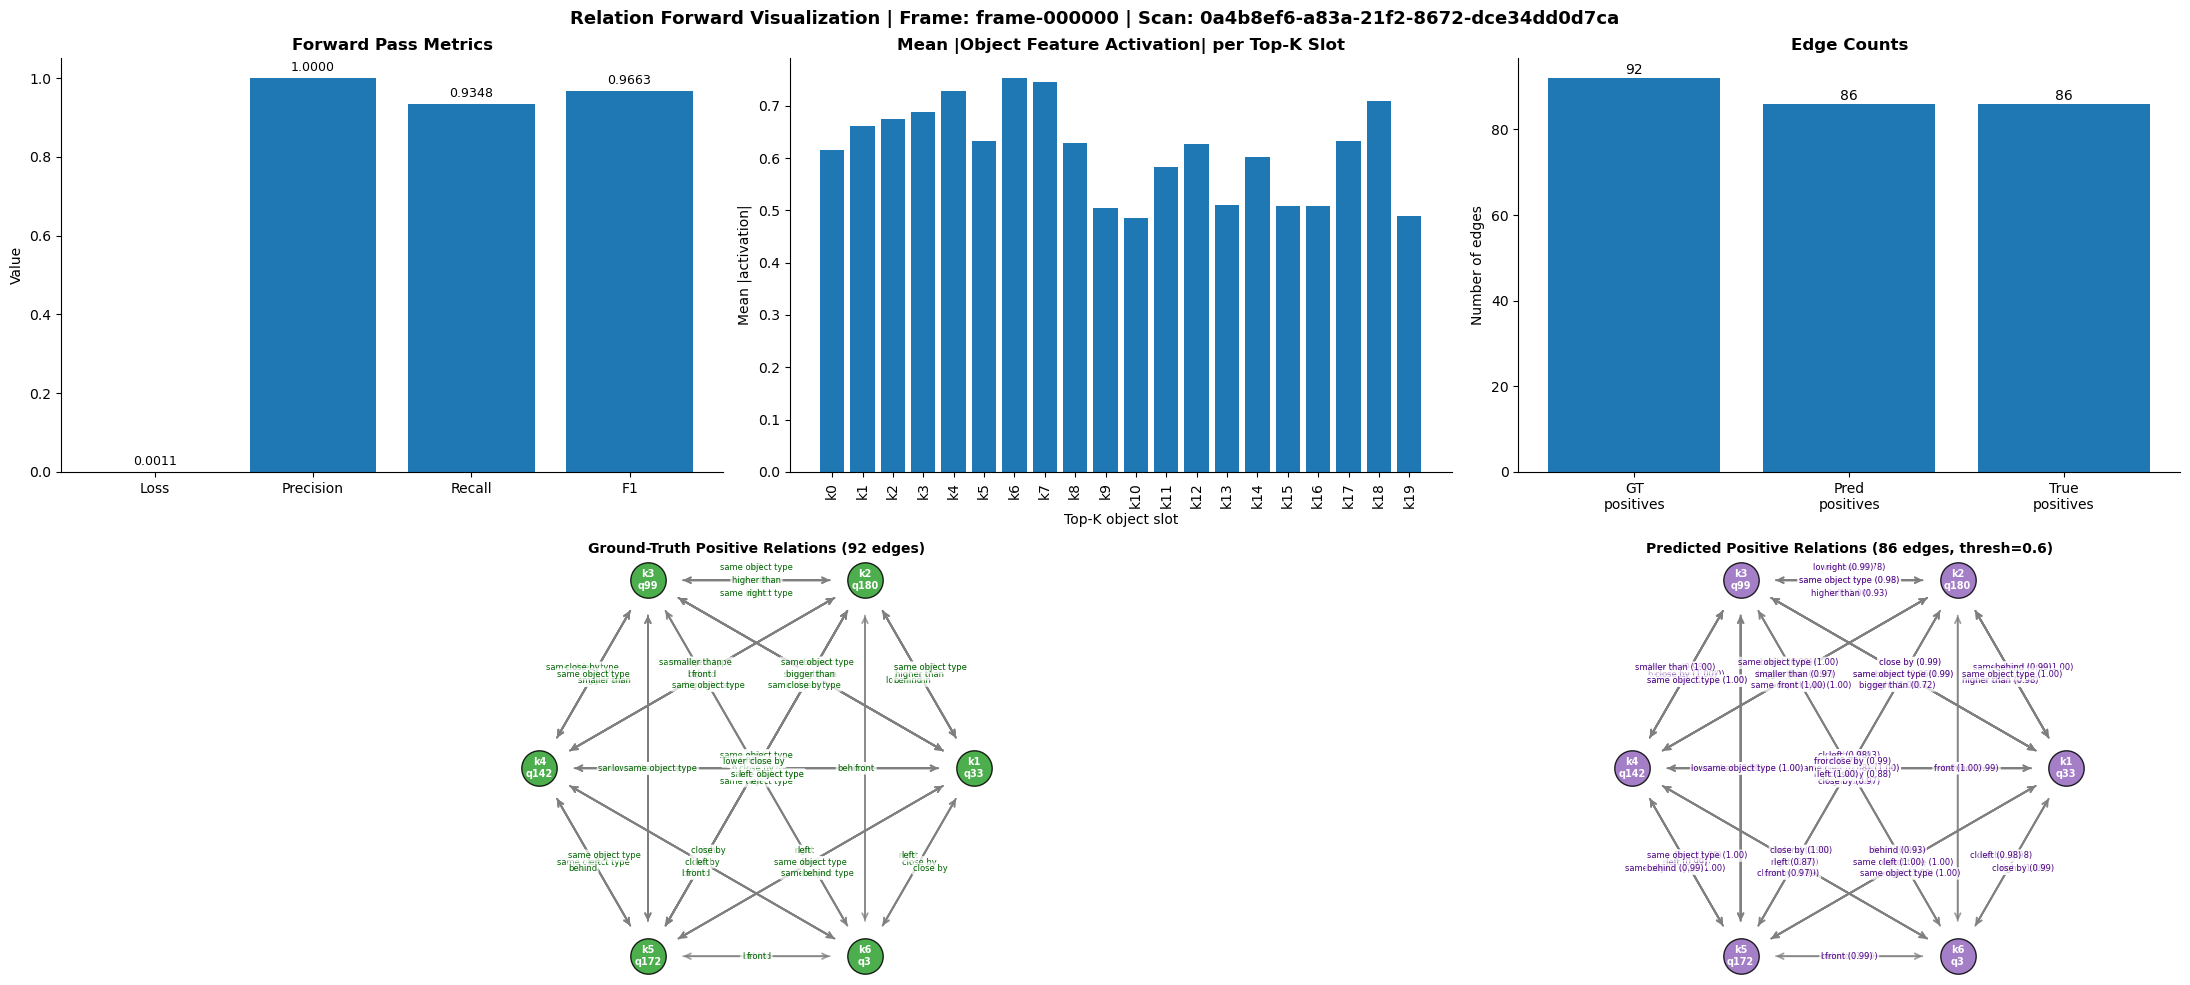


── Top-10 Predicted Positive Edges ──
  k 2/q180 → k 4/q142 [same object type] score=0.9999
  k 4/q142 → k 2/q180 [same object type] score=0.9998
  k 3/q 99 → k 4/q142 [bigger than] score=0.9998
  k 2/q180 → k 1/q 33 [same object type] score=0.9997
  k 3/q 99 → k 4/q142 [same object type] score=0.9996
  k 3/q 99 → k 5/q172 [same object type] score=0.9996
  k 4/q142 → k 5/q172 [same object type] score=0.9995
  k 5/q172 → k 3/q 99 [same object type] score=0.9995
  k 4/q142 → k 3/q 99 [smaller than] score=0.9995
  k 4/q142 → k 3/q 99 [same object type] score=0.9995

── All Ground-Truth Positive Edges ──
  k 1/q 33 → k 2/q180 [right]
  k 1/q 33 → k 2/q180 [front]
  k 1/q 33 → k 2/q180 [lower than]
  k 1/q 33 → k 2/q180 [same object type]
  k 1/q 33 → k 3/q 99 [left]
  k 1/q 33 → k 3/q 99 [front]
  k 1/q 33 → k 3/q 99 [close by]
  k 1/q 33 → k 3/q 99 [smaller than]
  k 1/q 33 → k 3/q 99 [same object type]
  k 1/q 33 → k 4/q142 [right]
  k 1/q 33 → k 4/q142 [close by]
  k 1/q 33 → k 4/q142 

In [45]:
# ─────────────────────────────────────────────────────────────────
# Cell: Forward Pass Visualization on First Relation JSON File
#       Works with object_features [20, 512], targets [20, 20, R]
# ─────────────────────────────────────────────────────────────────

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────
PRED_THRESHOLD = 0.6
sequence_dir = scans_root / "0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca" / "sequence"
json_files = sorted(sequence_dir.glob("frame-*.relation.json"))

if not json_files:
    raise FileNotFoundError(
        f"No .relation.json files found in {sequence_dir}. "
        "Run the updated object-feature relation dataset builder first."
    )

# Pick one frame
first_json_path = json_files[0]

print(f"Loading: {first_json_path.name}")

with open(first_json_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

frame_id = sample["frame_id"]
scan_id_sample = sample["scan_id"]
relation_names = sample["relation_names"]
num_relations = len(relation_names)
meta = sample.get("metadata", {})

if "object_features" not in sample:
    raise KeyError(
        "This JSON does not contain `object_features`. "
        "Run the updated query + pooled-pixel dataset builder first."
    )

object_features_np = np.array(sample["object_features"], dtype=np.float32)       # [20, 512]
queries_np = np.array(sample.get("queries", object_features_np), dtype=np.float32)
targets_np = np.array(sample["relationship_targets"], dtype=np.uint8)            # [20, 20, R]

topk_indices = meta.get("topk_indices", list(range(object_features_np.shape[0])))

object_features_t = torch.tensor(object_features_np, dtype=torch.float32).unsqueeze(0)
targets_t = torch.tensor(targets_np, dtype=torch.float32).unsqueeze(0)

print(f"Frame: {frame_id} | Scan: {scan_id_sample}")
print(f"Object features: {tuple(object_features_t.shape)} | Targets: {tuple(targets_t.shape)}")
print(f"GT positives: {int(targets_np.sum())}")
print(f"Relation classes: {num_relations}")
print(f"Top-K original query indices: {topk_indices}")

# ── Forward pass ──────────────────────────────────────────────────
device = next(rel_model.parameters()).device
rel_model.eval()

object_features_t = object_features_t.to(device)
targets_t = targets_t.to(device)

with torch.inference_mode():
    rel_logits = rel_model(object_features_t)      # [1, 20, 20, R]
    rel_probs = torch.sigmoid(rel_logits)

criterion_vis = torch.nn.BCEWithLogitsLoss()
loss_val = criterion_vis(rel_logits, targets_t).item()

pred_bin = (rel_probs > PRED_THRESHOLD).float()

tp = (pred_bin * targets_t).sum().item()
fp = (pred_bin * (1.0 - targets_t)).sum().item()
fn = ((1.0 - pred_bin) * targets_t).sum().item()

eps = 1e-8
precision = tp / (tp + fp + eps)
recall = tp / (tp + fn + eps)
f1 = 2 * precision * recall / (precision + recall + eps)

print(f"\n── Forward Pass Metrics | threshold={PRED_THRESHOLD} ──")
print(f"BCE Loss: {loss_val:.6f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"Pred positives: {int(pred_bin.sum().item())}")
print(f"GT positives: {int(targets_t.sum().item())}")

# ── Extract GT and predicted edges ────────────────────────────────
gt_targets_np = targets_np
pred_probs_np = rel_probs[0].detach().cpu().numpy()

gt_edges = []
pred_edges = []

num_queries = gt_targets_np.shape[0]

for src_q in range(num_queries):
    for dst_q in range(num_queries):
        if src_q == dst_q:
            continue

        for r in range(num_relations):
            if gt_targets_np[src_q, dst_q, r] == 1:
                gt_edges.append((src_q, dst_q, relation_names[r]))

        for r in range(num_relations):
            score = float(pred_probs_np[src_q, dst_q, r])
            if score >= PRED_THRESHOLD:
                pred_edges.append((src_q, dst_q, relation_names[r], score))

print(f"\nGT positive edges found: {len(gt_edges)}")
print(f"Pred positive edges found: {len(pred_edges)}")


def _draw_relation_graph(
    ax,
    edges,
    title,
    node_color="tab:blue",
    edge_color="tab:gray",
    label_color="darkred",
    show_score=False,
):
    if not edges:
        ax.set_title(title)
        ax.text(
            0,
            0,
            "No edges to display",
            ha="center",
            va="center",
            fontsize=11,
            color="tab:red",
        )
        ax.axis("off")
        return

    nodes = sorted({e[0] for e in edges} | {e[1] for e in edges})
    n = len(nodes)

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    pos = {
        nd: np.array([np.cos(a), np.sin(a)], dtype=np.float32)
        for nd, a in zip(nodes, angles)
    }

    for nd in nodes:
        x, y = pos[nd]
        original_q = topk_indices[nd] if nd < len(topk_indices) else nd

        ax.scatter(
            x,
            y,
            s=650,
            c=node_color,
            alpha=0.85,
            edgecolors="black",
            zorder=3,
        )

        ax.text(
            x,
            y,
            f"k{nd}\nq{original_q}",
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            zorder=4,
        )

    for idx, edge in enumerate(edges):
        src_q, dst_q, rel_name = edge[0], edge[1], edge[2]
        score = edge[3] if len(edge) > 3 else None

        src_xy = pos[src_q]
        dst_xy = pos[dst_q]

        vec = dst_xy - src_xy
        norm = np.linalg.norm(vec)

        if norm < 1e-8:
            continue

        unit = vec / norm
        start = src_xy + unit * 0.15
        end = dst_xy - unit * 0.15

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(
                arrowstyle="->",
                lw=1.3,
                color=edge_color,
                alpha=0.75,
            ),
            zorder=2,
        )

        mid = (start + end) * 0.5
        perp = np.array([-unit[1], unit[0]], dtype=np.float32)
        offset = ((idx % 3) - 1) * 0.06
        text_pos = mid + perp * offset

        label = (
            f"{rel_name} ({score:.2f})"
            if show_score and score is not None
            else rel_name
        )

        ax.text(
            text_pos[0],
            text_pos[1],
            label,
            fontsize=6,
            color=label_color,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.75,
                edgecolor="none",
            ),
            zorder=5,
        )

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


# ── Plot ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 10))

fig.suptitle(
    f"Relation Forward Visualization | Frame: {frame_id} | Scan: {scan_id_sample}",
    fontsize=13,
    fontweight="bold",
)

# Metrics
ax_bar = fig.add_subplot(2, 3, 1)

metrics = {
    "Loss": loss_val,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
}

bars = ax_bar.bar(list(metrics.keys()), list(metrics.values()))
ax_bar.set_ylim(0, max(1.05, loss_val * 1.1))
ax_bar.set_title("Forward Pass Metrics", fontweight="bold")
ax_bar.set_ylabel("Value")

for bar, val in zip(bars, metrics.values()):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax_bar.spines[["top", "right"]].set_visible(False)

# Object feature activations
ax_heat = fig.add_subplot(2, 3, 2)

mean_act = np.abs(object_features_np).mean(axis=1)  # [20]

ax_heat.bar(np.arange(len(mean_act)), mean_act, width=0.8)
ax_heat.set_title("Mean |Object Feature Activation| per Top-K Slot", fontweight="bold")
ax_heat.set_xlabel("Top-K object slot")
ax_heat.set_ylabel("Mean |activation|")
ax_heat.set_xticks(np.arange(len(mean_act)))
ax_heat.set_xticklabels([f"k{i}" for i in range(len(mean_act))], rotation=90)
ax_heat.spines[["top", "right"]].set_visible(False)

# Counts
ax_cnt = fig.add_subplot(2, 3, 3)

categories = ["GT\npositives", "Pred\npositives", "True\npositives"]
counts = [len(gt_edges), len(pred_edges), int(tp)]

ax_cnt.bar(categories, counts)
ax_cnt.set_title("Edge Counts", fontweight="bold")
ax_cnt.set_ylabel("Number of edges")

for i, v in enumerate(counts):
    ax_cnt.text(i, v + 0.2, str(v), ha="center", va="bottom", fontsize=10)

ax_cnt.spines[["top", "right"]].set_visible(False)

# GT graph
ax_gt = fig.add_subplot(2, 3, (4, 5))

_draw_relation_graph(
    ax_gt,
    gt_edges,
    title=f"Ground-Truth Positive Relations ({len(gt_edges)} edges)",
    node_color="tab:green",
    edge_color="tab:gray",
    label_color="darkgreen",
)

# Pred graph
ax_pred = fig.add_subplot(2, 3, 6)

_draw_relation_graph(
    ax_pred,
    pred_edges,
    title=f"Predicted Positive Relations ({len(pred_edges)} edges, thresh={PRED_THRESHOLD})",
    node_color="tab:purple",
    edge_color="tab:gray",
    label_color="indigo",
    show_score=True,
)

plt.tight_layout()
plt.show()

# ── Print top predicted edges ─────────────────────────────────────
print("\n── Top-10 Predicted Positive Edges ──")

top_edges = sorted(pred_edges, key=lambda x: x[3], reverse=True)[:10]

if top_edges:
    for src_q, dst_q, rel_name, score in top_edges:
        src_orig = topk_indices[src_q] if src_q < len(topk_indices) else src_q
        dst_orig = topk_indices[dst_q] if dst_q < len(topk_indices) else dst_q

        print(
            f"  k{src_q:>2}/q{src_orig:>3} → "
            f"k{dst_q:>2}/q{dst_orig:>3} "
            f"[{rel_name}] score={score:.4f}"
        )
else:
    print("  (none above threshold)")


print("\n── All Ground-Truth Positive Edges ──")

if gt_edges:
    for src_q, dst_q, rel_name in gt_edges:
        src_orig = topk_indices[src_q] if src_q < len(topk_indices) else src_q
        dst_orig = topk_indices[dst_q] if dst_q < len(topk_indices) else dst_q

        print(
            f"  k{src_q:>2}/q{src_orig:>3} → "
            f"k{dst_q:>2}/q{dst_orig:>3} "
            f"[{rel_name}]"
        )
else:
    print("  (no GT positive edges in this frame)")

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# =========================
# Config
# =========================
image_path = "/home/station2/Zermat/RTSGS-SLAM/Datasets/Replica/ThirdParty/Replica/office2/results/frame001300.jpg"

checkpoint = "facebook/mask2former-swin-large-ade-panoptic"
TOP_K = 20
REL_THRESHOLD = 0.6

relationships_txt = "/home/station2/Zermat/RTSGS-SLAM/Datasets/3DSSG/relationships.txt"

required_vars = ["rel_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing: {missing}. Run your trained relation-head cell first.")

# =========================
# Helpers
# =========================
def get_pixel_decoder_features(outputs):
    if (
        hasattr(outputs, "pixel_decoder_last_hidden_state")
        and outputs.pixel_decoder_last_hidden_state is not None
    ):
        return outputs.pixel_decoder_last_hidden_state

    if (
        hasattr(outputs, "pixel_decoder_hidden_states")
        and outputs.pixel_decoder_hidden_states is not None
    ):
        return outputs.pixel_decoder_hidden_states[-1]

    raise RuntimeError(
        "Pixel decoder features not found. "
        "Run Mask2Former with output_hidden_states=True."
    )


def mask_pool_pixel_features(pixel_features, mask_logits):
    """
    pixel_features: [1, C, Hf, Wf]
    mask_logits:    [1, N, Hm, Wm]
    returns:        [N, C]
    """
    if mask_logits.shape[-2:] != pixel_features.shape[-2:]:
        mask_logits = F.interpolate(
            mask_logits,
            size=pixel_features.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    masks = torch.sigmoid(mask_logits)
    masks = masks / (masks.sum(dim=(2, 3), keepdim=True) + 1e-6)

    pooled = torch.einsum("bchw,bnhw->bnc", pixel_features, masks)
    return pooled.squeeze(0)


def colorize_id_map(id_map):
    unique_ids = np.unique(id_map)
    rng = np.random.default_rng(0)
    colors = rng.random((len(unique_ids), 3), dtype=np.float32)

    out = np.zeros((*id_map.shape, 3), dtype=np.float32)
    for i, uid in enumerate(unique_ids):
        out[id_map == uid] = colors[i]
    return out


def draw_relation_graph(ax, edges, title):
    if len(edges) == 0:
        ax.set_title(title)
        ax.text(0, 0, "No relations predicted", ha="center", va="center", color="red")
        ax.axis("off")
        return

    nodes = sorted(set([e["src_k"] for e in edges] + [e["dst_k"] for e in edges]))
    n = len(nodes)

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = {
        node: np.array([np.cos(a), np.sin(a)], dtype=np.float32)
        for node, a in zip(nodes, angles)
    }

    for node in nodes:
        x, y = pos[node]
        label_name = seg_model.config.id2label.get(int(topk_labels[node]), "unknown")

        ax.scatter(x, y, s=800, edgecolors="black", zorder=3)
        ax.text(
            x,
            y,
            f"k{node}\n{label_name[:10]}",
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            zorder=4,
        )

    for idx, e in enumerate(edges[:40]):
        src = e["src_k"]
        dst = e["dst_k"]

        src_xy = pos[src]
        dst_xy = pos[dst]

        vec = dst_xy - src_xy
        norm = np.linalg.norm(vec)
        if norm < 1e-8:
            continue

        unit = vec / norm
        start = src_xy + unit * 0.16
        end = dst_xy - unit * 0.16

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="->", lw=1.2, alpha=0.7),
            zorder=2,
        )

        mid = (start + end) * 0.5
        perp = np.array([-unit[1], unit[0]], dtype=np.float32)
        text_pos = mid + perp * (((idx % 3) - 1) * 0.06)

        ax.text(
            text_pos[0],
            text_pos[1],
            f"{e['rel_name']} ({e['score']:.2f})",
            fontsize=6,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75),
            zorder=5,
        )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


# =========================
# Load relation names
# =========================
with open(relationships_txt, "r", encoding="utf-8") as f:
    relation_names = [line.strip() for line in f if line.strip()]

# =========================
# Load image
# =========================
image = Image.open(image_path).convert("RGB")

device = next(rel_model.parameters()).device
rel_model.eval()

# =========================
# Load Mask2Former
# =========================
processor = AutoImageProcessor.from_pretrained(checkpoint)
seg_model = Mask2FormerForUniversalSegmentation.from_pretrained(checkpoint).to(device)
seg_model.eval()

inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# =========================
# Mask2Former forward
# =========================
with torch.inference_mode():
    outputs = seg_model(
        **inputs,
        output_hidden_states=True,
    )

    panoptic = processor.post_process_panoptic_segmentation(
        outputs,
        target_sizes=[image.size[::-1]],
        threshold=0.3,
        mask_threshold=0.3,
        overlap_mask_area_threshold=0.7,
    )[0]

predicted_panoptic_map = panoptic["segmentation"].detach().cpu().numpy()
segments_info = panoptic["segments_info"]

print("Mask2Former output:")
print("  class logits:", tuple(outputs.class_queries_logits.shape))
print("  mask logits :", tuple(outputs.masks_queries_logits.shape))
print("  queries     :", tuple(outputs.transformer_decoder_last_hidden_state.shape))
print("  segments    :", len(segments_info))

# =========================
# Select top-K queries + pooled pixel decoder features
# =========================
class_logits = outputs.class_queries_logits[0]                    # [200, C+1]
query_embeds = outputs.transformer_decoder_last_hidden_state[0]   # [200, 256]
mask_logits = outputs.masks_queries_logits                        # [1, 200, Hm, Wm]

probs = F.softmax(class_logits, dim=-1)

query_scores, query_labels = probs[:, :-1].max(dim=-1)

topk = torch.topk(query_scores, k=TOP_K)

topk_indices = topk.indices.detach().cpu().tolist()
topk_scores = topk.values.detach().cpu().tolist()
topk_labels = query_labels[topk.indices].detach().cpu().tolist()

topk_queries = query_embeds[topk.indices]  # [20, 256]

pixel_features = get_pixel_decoder_features(outputs).detach()  # [1, 256, Hf, Wf]

pooled_pixel_features_full = mask_pool_pixel_features(
    pixel_features=pixel_features,
    mask_logits=mask_logits.detach(),
)  # [200, 256]

topk_pooled_pixel_features = pooled_pixel_features_full[topk.indices]  # [20, 256]

object_features = torch.cat(
    [
        topk_queries.detach().cpu(),
        topk_pooled_pixel_features.detach().cpu(),
    ],
    dim=-1,
).unsqueeze(0).to(device)  # [1, 20, 512]

print("\nFeature shapes:")
print("  topk_queries:", tuple(topk_queries.shape))
print("  topk_pooled_pixel_features:", tuple(topk_pooled_pixel_features.shape))
print("  object_features:", tuple(object_features.shape))

print("\nTop-K objects:")
for rank, (qid, score, label_id) in enumerate(zip(topk_indices, topk_scores, topk_labels)):
    label_name = seg_model.config.id2label.get(int(label_id), "unknown")
    print(f"  k{rank:02d} | old_query={qid:03d} | score={score:.4f} | label={label_name}")

# =========================
# Relation-head inference
# =========================
with torch.inference_mode():
    rel_logits = rel_model(object_features)  # [1, 20, 20, R]
    rel_probs = torch.sigmoid(rel_logits)[0].cpu().numpy()

print("\nRelation head output:")
print("  rel_logits:", tuple(rel_logits.shape))
print("  rel_probs :", rel_probs.shape)

# =========================
# Extract predicted edges
# =========================
pred_edges = []

for src_k in range(TOP_K):
    for dst_k in range(TOP_K):
        if src_k == dst_k:
            continue

        for rel_id in range(rel_probs.shape[-1]):
            score = float(rel_probs[src_k, dst_k, rel_id])

            if score >= REL_THRESHOLD:
                rel_name = (
                    relation_names[rel_id]
                    if rel_id < len(relation_names)
                    else f"rel_{rel_id}"
                )

                pred_edges.append({
                    "src_k": src_k,
                    "dst_k": dst_k,
                    "src_old_query": topk_indices[src_k],
                    "dst_old_query": topk_indices[dst_k],
                    "src_label": seg_model.config.id2label.get(int(topk_labels[src_k]), "unknown"),
                    "dst_label": seg_model.config.id2label.get(int(topk_labels[dst_k]), "unknown"),
                    "rel_id": rel_id,
                    "rel_name": rel_name,
                    "score": score,
                })

pred_edges = sorted(pred_edges, key=lambda x: x["score"], reverse=True)

print(f"\nPredicted relations above threshold {REL_THRESHOLD}: {len(pred_edges)}")
for e in pred_edges[:30]:
    print(
        f"k{e['src_k']:02d}:{e['src_label']} "
        f"--[{e['rel_name']} {e['score']:.3f}]--> "
        f"k{e['dst_k']:02d}:{e['dst_label']}"
    )

# =========================
# Prepare plots
# =========================
image_np = np.array(image).astype(np.float32) / 255.0

panoptic_color = colorize_id_map(predicted_panoptic_map)
panoptic_overlay = 0.5 * image_np + 0.5 * panoptic_color

topk_masks = torch.sigmoid(outputs.masks_queries_logits[0, topk.indices]).detach().cpu().numpy()

img_h, img_w = predicted_panoptic_map.shape

topk_masks_t = torch.tensor(topk_masks).unsqueeze(1)
topk_masks_up = F.interpolate(
    topk_masks_t,
    size=(img_h, img_w),
    mode="bilinear",
    align_corners=False,
).squeeze(1).numpy()

topk_mask_id = np.zeros((img_h, img_w), dtype=np.int32)

for k in range(TOP_K):
    mask = topk_masks_up[k] > 0.5
    topk_mask_id[mask] = k + 1

topk_mask_color = colorize_id_map(topk_mask_id)
topk_overlay = 0.5 * image_np + 0.5 * topk_mask_color

# =========================
# Plot every step
# =========================
fig = plt.figure(figsize=(24, 14))

fig.suptitle(
    f"Relation Prediction Pipeline\n{Path(image_path).name}",
    fontsize=14,
    fontweight="bold",
)

ax1 = fig.add_subplot(2, 3, 1)
ax1.imshow(image)
ax1.set_title("1. Input Image")
ax1.axis("off")

ax2 = fig.add_subplot(2, 3, 2)
ax2.imshow(panoptic_overlay)
ax2.set_title(f"2. Mask2Former Panoptic Overlay\nsegments={len(segments_info)}")
ax2.axis("off")

ax3 = fig.add_subplot(2, 3, 3)
ax3.imshow(topk_overlay)
ax3.set_title("3. Top-K Query Masks Overlay")
ax3.axis("off")

ax4 = fig.add_subplot(2, 3, 4)
ax4.bar(np.arange(TOP_K), topk_scores)
ax4.set_title("4. Top-K Query Confidence")
ax4.set_xlabel("top-K slot")
ax4.set_ylabel("object confidence")
ax4.set_xticks(np.arange(TOP_K))
ax4.set_xticklabels([f"k{i}\nq{topk_indices[i]}" for i in range(TOP_K)], rotation=90)

ax5 = fig.add_subplot(2, 3, 5)
draw_relation_graph(
    ax5,
    pred_edges,
    title=f"5. Predicted Relations Graph\nedges={len(pred_edges)}, threshold={REL_THRESHOLD}",
)

ax6 = fig.add_subplot(2, 3, 6)

edge_counts = {}
for e in pred_edges:
    edge_counts[e["rel_name"]] = edge_counts.get(e["rel_name"], 0) + 1

if len(edge_counts) > 0:
    names = list(edge_counts.keys())
    counts = list(edge_counts.values())
    order = np.argsort(counts)[::-1]

    names = [names[i] for i in order[:15]]
    counts = [counts[i] for i in order[:15]]

    ax6.barh(names[::-1], counts[::-1])
    ax6.set_title("6. Top Predicted Relation Types")
    ax6.set_xlabel("count")
else:
    ax6.text(0.5, 0.5, "No relation types", ha="center", va="center")
    ax6.set_title("6. Top Predicted Relation Types")

plt.tight_layout()
plt.show()

RuntimeError: Missing: ['rel_model']. Run your trained relation-head cell first.

In [61]:
# =========================
# Save model checkpoint
# =========================

from pathlib import Path
import torch

def save_checkpoint(
    model,
    optimizer,
    epoch,
    save_path,
    best_f1=None,
    extra=None
):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_f1": best_f1,
        "config": {
            "hidden_dim": hidden_dim,
            "num_rel_classes": num_rel_classes,
            "threshold": threshold,
            "neg_ratio": neg_ratio,
        }
    }

    if extra is not None:
        checkpoint["extra"] = extra

    torch.save(checkpoint, save_path)
    print(f"✅ Model saved to: {save_path}")


# Example usage
save_checkpoint(
    model=rel_model,
    optimizer=optimizer,
    epoch=epoch,
    save_path=save_path,  # your existing path
    best_f1=va_f1
)

✅ Model saved to: /home/station2/Zermat/RTSGS-SLAM/Datasets/3Rscan/3RScan/data/scans/relation_branch_hard_negative_bce.pt
